In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from tqdm import tqdm
from sklearn.model_selection import train_test_split
SEED = 42
np.random.seed(SEED)
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix


# 1. Exploratory Data Analysis

Before preprocessing, we explore the dataset to understand its structure, class distribution, and any potential data quality issues. This helps us make informed preprocessing decisions.

**Dataset:** Brain MRI Images for Tumor Classification  
**Source structure:** Pre-split into "Training" and "Testing" folders, each containing one subfolder per class.  
**Classes:** glioma, meningioma, notumor, pituitary (4-class classification)  
**Raw image shape:** 512 × 512 × 3 (color, but MRI color carries no diagnostic meaning)  
**Total training images:** 5,600 &nbsp; , &nbsp; **Total testing images:** 1,600 &nbsp; , &nbsp; **Total images:** 7,200

In [ ]:
dataset_path =r"/content/drive/MyDrive/The original data"
TRAIN_PATH   = os.path.join(dataset_path, "Training")
TEST_PATH    = os.path.join(dataset_path, "Testing")
LABELS       = ['glioma', 'meningioma', 'notumor', 'pituitary']

# Count images per class
train_counts = {}
test_counts  = {}
corrupted    = []
duplicates   = []

for label in LABELS:
    train_folder = os.path.join(TRAIN_PATH, label)
    test_folder  = os.path.join(TEST_PATH,  label)

    train_files = [f for f in os.listdir(train_folder) if f.lower().endswith(('.jpg','.jpeg','.png'))]
    test_files  = [f for f in os.listdir(test_folder)  if f.lower().endswith(('.jpg','.jpeg','.png'))]

    train_counts[label] = len(train_files)
    test_counts[label]  = len(test_files)

    # check for corrupted files(equivalent to the concept of the missing values )
    for f in train_files:
        img = cv2.imread(os.path.join(train_folder, f))
        if img is None:
            corrupted.append(f)

    # check for duplicates by filename
    seen = set()
    for f in train_files:
        if f in seen:
            duplicates.append(f)
        seen.add(f)

# read one sample to get image shape
sample_img = cv2.imread(os.path.join(TRAIN_PATH, LABELS[0],os.listdir(os.path.join(TRAIN_PATH, LABELS[0]))[0]))

print(" - Dataset Summary : ")
print()
print(f"Image shape (raw)     : {sample_img.shape}")
print(f"Total training images : {sum(train_counts.values())}")
print(f"Total testing images  : {sum(test_counts.values())}")
print(f"Total images          : {sum(train_counts.values()) + sum(test_counts.values())}")
print(f"Number of classes     : {len(LABELS)}")
print(f"Classes               : {LABELS}")
print()
print("Training images per class:")
for label, count in train_counts.items():
    print(f"  {label:15s}: {count}")
print()
print("Testing images per class:")
for label, count in test_counts.items():
    print(f"  {label:15s}: {count}")

 - Dataset Summary : 

Image shape (raw)     : (512, 512, 3)
Total training images : 5600
Total testing images  : 1600
Total images          : 7200
Number of classes     : 4
Classes               : ['glioma', 'meningioma', 'notumor', 'pituitary']

Training images per class:
  glioma         : 1400
  meningioma     : 1400
  notumor        : 1400
  pituitary      : 1400

Testing images per class:
  glioma         : 400
  meningioma     : 400
  notumor        : 400
  pituitary      : 400


## 1.1 Data Quality Check

We check for three common data quality issues before any processing:
- **Corrupted files:** Images that OpenCV cannot read (treated as missing data for pixel arrays  NaN values do not apply to images).
- **Duplicate filenames:** Files with the same name within a class folder.
- **Class imbalance:** Whether any class has significantly more or fewer samples than others.

In [ ]:
print("DATA QUALITY REPORT")

# corrupted files
if len(corrupted) == 0:
    print("Corrupted files   : None found")
else:
    print(f"Corrupted files   : {len(corrupted)} found → {corrupted}")

# duplicates
if len(duplicates) == 0:
    print("Duplicate files   : None found")
else:
    print(f"Duplicate files   : {len(duplicates)} found → {duplicates}")

# missing values (MRI images are pixel arrays, not tabular data)
# so NaN values do not apply. We treat unreadable files as missing data instead.
# class imbalance note
max_class = max(train_counts, key=train_counts.get)
min_class = min(train_counts, key=train_counts.get)
diff = train_counts[max_class] - train_counts[min_class]
print(f"\nClass imbalance   : Largest class  '{max_class}' = {train_counts[max_class]}")
print(f"                    Smallest class '{min_class}' = {train_counts[min_class]}")
print(f"                    Difference = {diff} images")

DATA QUALITY REPORT
Corrupted files   : None found
Duplicate files   : None found

Class imbalance   : Largest class  'glioma' = 1400
                    Smallest class 'glioma' = 1400
                    Difference = 0 images


## 1.2 Class Distribution

A bar chart showing the number of images per class in both training and testing sets.  
This helps detect class imbalance, which can bias a model toward the majority class.

**Observation:** The dataset is perfectly balanced exactly 1,400 training images and 400 testing images per class. No class weighting or oversampling is needed. We still apply stratified splitting as a best practice to preserve this balance in every split.

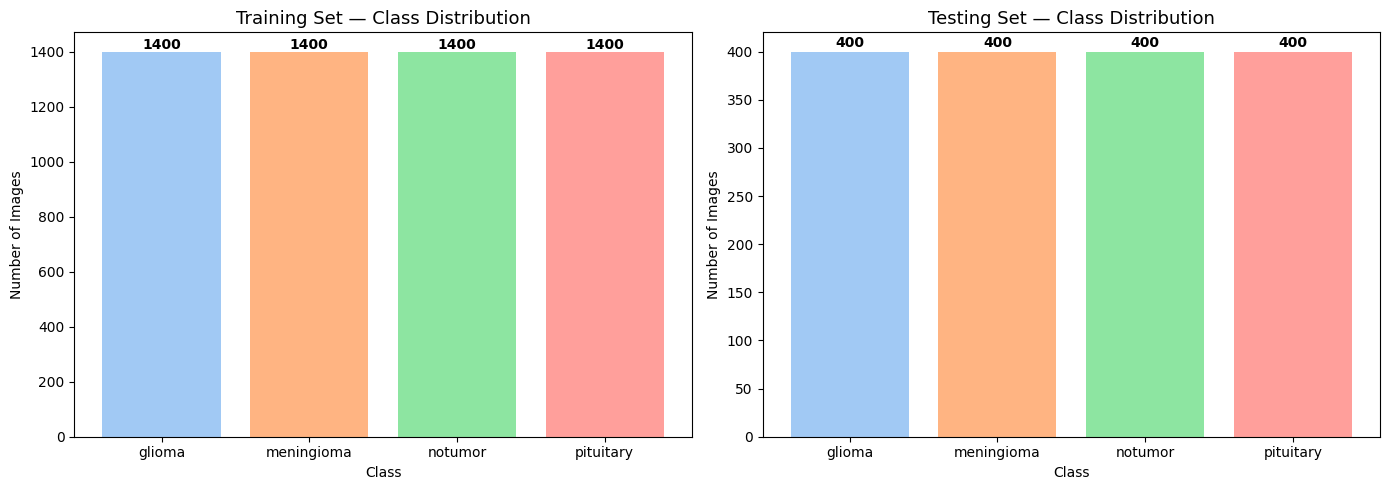


Observation: The dataset is perfectly balanced across all 4 classes.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# training bar chart
colors = sns.color_palette('pastel', len(LABELS))
axes[0].bar(train_counts.keys(), train_counts.values(), color=colors)
axes[0].set_title("Training Set — Class Distribution", fontsize=13)
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Number of Images")
for i, (label, count) in enumerate(train_counts.items()):
    axes[0].text(i, count + 10, str(count), ha='center', fontweight='bold')

# testing bar chart
axes[1].bar(test_counts.keys(), test_counts.values(), color=colors)
axes[1].set_title("Testing Set — Class Distribution", fontsize=13)
axes[1].set_xlabel("Class")
axes[1].set_ylabel("Number of Images")
for i, (label, count) in enumerate(test_counts.items()):
    axes[1].text(i, count + 5, str(count), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\nObservation: The dataset is perfectly balanced across all 4 classes.")

## 1.3 Sample Image Grid

Displaying 5 sample images from each class gives intuition about what the model will learn to distinguish.  
Key observations from the grid:
- Images come from different MRI scan orientations (axial, sagittal, coronal), which adds natural variation.
- Tumor regions vary in size, shape, and location across classes.
- Some images have large black borders around the brain , this motivates our brain-cropping step in preprocessing.
- The "no tumor" class contains scans from different MRI modalities (T1, T2, CT), making it the most visually diverse class.

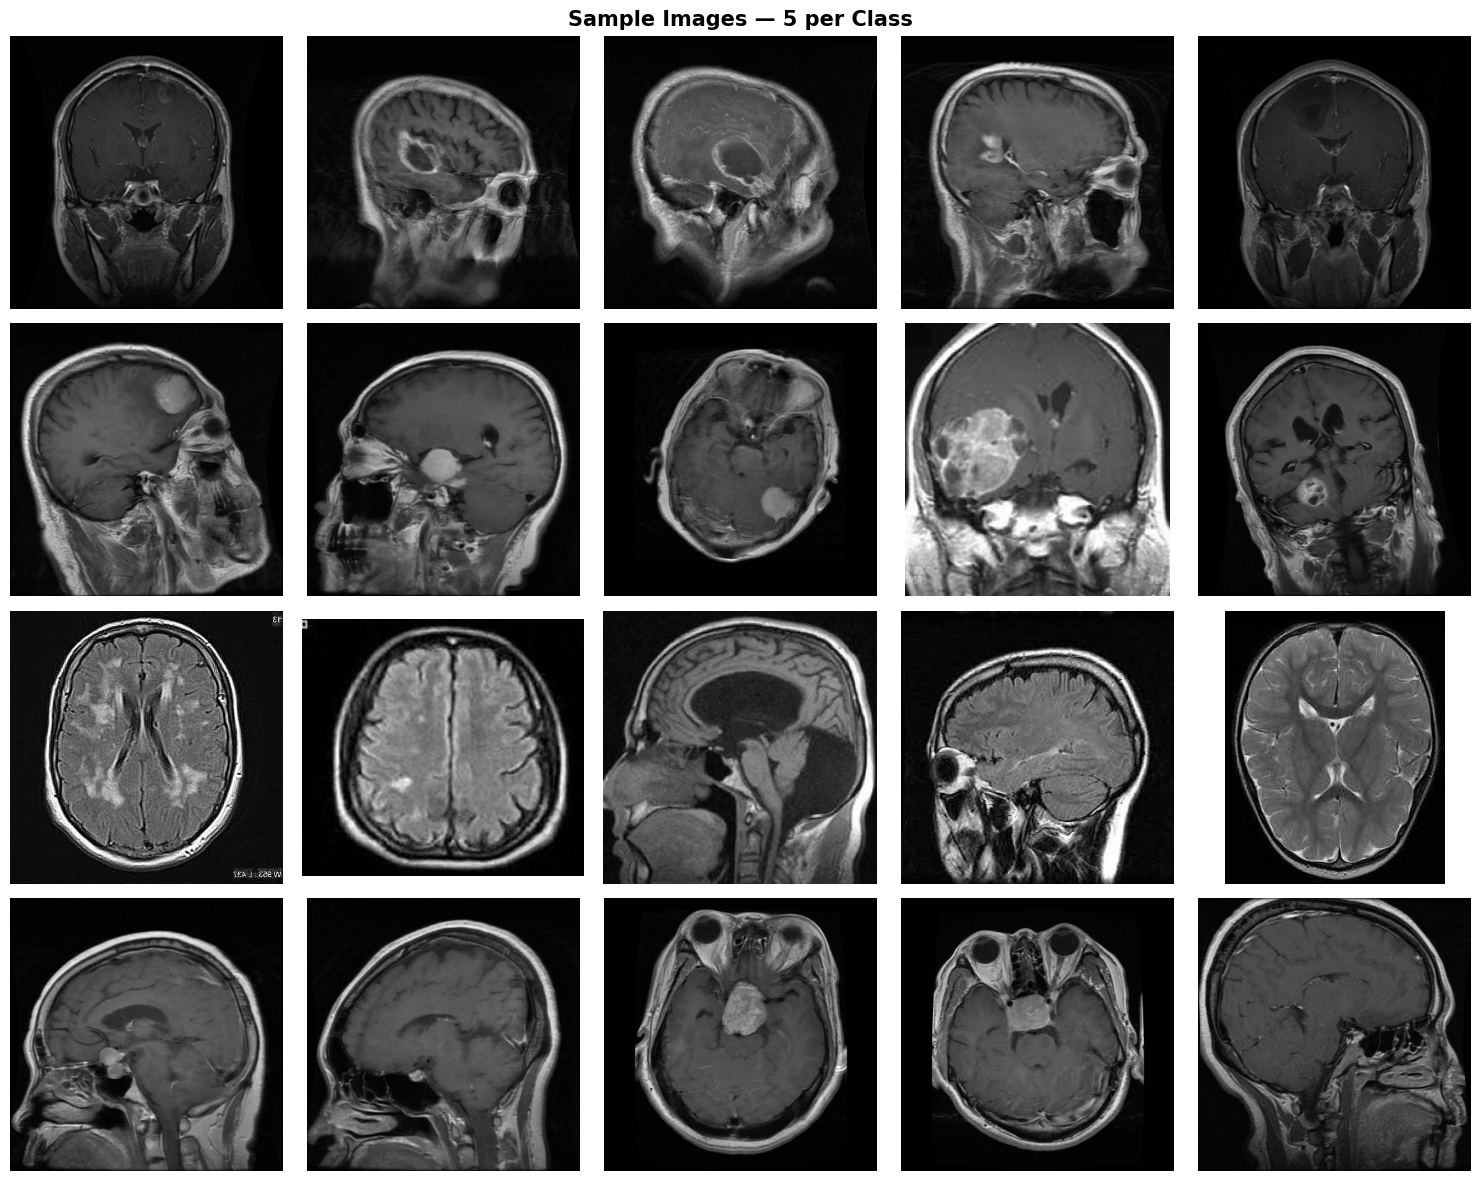

In [ ]:
fig, axes = plt.subplots(len(LABELS), 5, figsize=(15, 12))

for row, label in enumerate(LABELS):
    label_folder = os.path.join(TRAIN_PATH, label)
    image_files  = [f for f in os.listdir(label_folder)
                    if f.lower().endswith(('.jpg', '.jpeg', '.png'))][:5]

    for col, fname in enumerate(image_files):
        img = cv2.imread(os.path.join(label_folder, fname))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[row, col].imshow(img)
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_ylabel(label, fontsize=12, fontweight='bold')

plt.suptitle("Sample Images — 5 per Class", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 1.4 Pixel Intensity Histogram  :

A histogram of raw pixel values confirms that normalization is necessary.  
Raw MRI pixel values span 0–255, which is too large a range for stable neural network training , large input values cause large gradients and slow or unstable convergence.  
After dividing by 255, all values fall in [0.0, 1.0], which is the standard input range for neural networks.  
The shape of the distribution is identical before and after , only the scale changes, which is exactly what normalization should do.

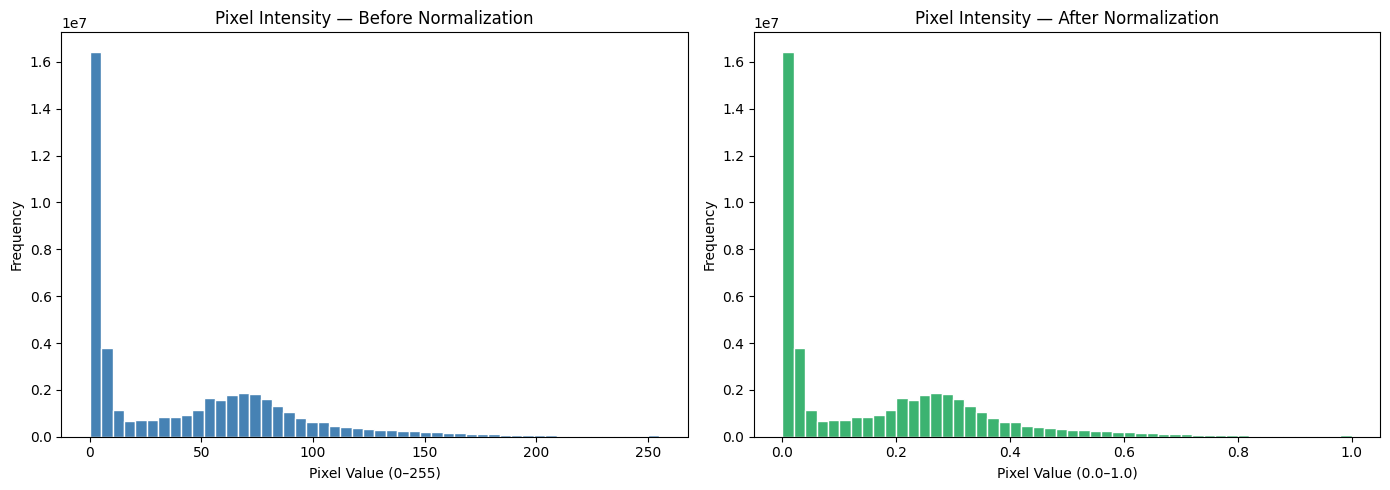

Before :  min: 0,  max: 255
After  :  min: 0.0, max: 1.0


In [ ]:
# load a few raw images to show pixel distribution before preprocessing
raw_pixels = []
for label in LABELS:
    label_folder = os.path.join(TRAIN_PATH, label)
    files = [f for f in os.listdir(label_folder)
             if f.lower().endswith(('.jpg','.jpeg','.png'))][:50]
    for f in files:
        img = cv2.imread(os.path.join(label_folder, f), cv2.IMREAD_GRAYSCALE)
        if img is not None:
            raw_pixels.extend(img.flatten())

raw_pixels       = np.array(raw_pixels)
normalized_pixels = raw_pixels / 255.0

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(raw_pixels, bins=50, color='steelblue', edgecolor='white')
axes[0].set_title("Pixel Intensity — Before Normalization", fontsize=12)
axes[0].set_xlabel("Pixel Value (0–255)")
axes[0].set_ylabel("Frequency")

axes[1].hist(normalized_pixels, bins=50, color='mediumseagreen', edgecolor='white')
axes[1].set_title("Pixel Intensity — After Normalization", fontsize=12)
axes[1].set_xlabel("Pixel Value (0.0–1.0)")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

print(f"Before :  min: {raw_pixels.min()},  max: {raw_pixels.max()}")
print(f"After  :  min: {normalized_pixels.min():.1f}, max: {normalized_pixels.max():.1f}")

# 2. Preprocessing Pipeline

We apply the following steps to every image before feeding it to the neural network.  
The full pipeline is executed in the following order:

1. **Brain cropping:** Remove black background borders using contour detection to isolate the brain region.  
2. **Grayscale conversio**n: MRI intensity values are more relevant than color information.
3. **Resize to 128 × 128**: Standardize all images to the same spatial dimensions.  
4. **CLAHE (Contrast Limited Adaptive Histogram Equalization)** Enhances local contrast across the image using adaptive histogram equalization, making fine brain structures more distinguishable while preventing over-amplification of noise.
5. **Normalization:** Scale pixel values from [0, 255] to [0.0, 1.0] to stabilize training.  
6. **Channel expansion:** Reshape images to (128, 128, 1) to match CNN input requirements.  

Each step is essential for improving data consistency and model performance.

In [ ]:
OUTPUT_PATH    = "output"
PROCESSED_PATH = os.path.join(OUTPUT_PATH, "processed")
PLOTS_PATH     = os.path.join(OUTPUT_PATH, "plots")
IMG_SIZE       = 128

os.makedirs(PROCESSED_PATH, exist_ok=True)
os.makedirs(PLOTS_PATH, exist_ok=True)



def extract_contour(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    _, thresh = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if not contours:
        return image

    c = max(contours, key=cv2.contourArea)

    top    = tuple(c[c[:, :, 1].argmin()][0])
    bottom = tuple(c[c[:, :, 1].argmax()][0])
    left   = tuple(c[c[:, :, 0].argmin()][0])
    right  = tuple(c[c[:, :, 0].argmax()][0])

    cropped = image[top[1]:bottom[1], left[0]:right[0]]

    if cropped is None or cropped.size == 0:
        return image

    return cropped



# Preprocessing
def preprocess_image(image):
    # 1. crop
    cropped = extract_contour(image)

    # 2. grayscale
    gray = cv2.cvtColor(cropped, cv2.COLOR_BGR2GRAY)

    # 3. resize & CLAHE
    resized = cv2.resize(gray, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_CUBIC)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    equalized = clahe.apply(resized)
    # 4. normalize
    normalized = equalized.astype(np.float32) / 255.0
    normalized = np.clip(normalized, 0.0, 1.0)

    # 5. channel
    final = np.expand_dims(normalized, axis=-1)

    return final



def save_plot(original, processed, label):
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))

    axes[0].imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
    axes[0].set_title("Original")
    axes[0].axis("off")

    axes[1].imshow(processed, cmap='gray')
    axes[1].set_title("Preprocessed")
    axes[1].axis("off")

    plt.suptitle(f"Class: {label}")
    plt.tight_layout()

    # overwrites the file every run with the latest plot
    plt.savefig(os.path.join(PLOTS_PATH, f"{label}.png"), dpi=120)
    plt.show()
    plt.close()



def load_data(folder_path, labels, plot=False):
    X, y = [], []

    for label_index, label in enumerate(labels):
        label_folder = os.path.join(folder_path, label)

        image_files = [
            f for f in os.listdir(label_folder)
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))
        ]

        for i, filename in enumerate(tqdm(image_files, desc=f"Loading {label}")):
            img_path = os.path.join(label_folder, filename)
            image = cv2.imread(img_path)

            if image is None:
                continue

            processed = preprocess_image(image)
            X.append(processed)
            y.append(label_index)

            if i == 0 and plot:
                save_plot(image, processed[:, :, 0], label)

    return np.array(X, dtype=np.float32), np.array(y)

## 2.1 Loading, Splitting, and Augmentation

**Loading:** All images are loaded and passed through the full preprocessing pipeline defined above. Corrupted files (unreadable by OpenCV) are silently skipped.

**Train / Validation / Test split:**  
The original test set (1,600 images) is kept completely separate and is never used during training or validation. From the training set (5,600 images), we split off 30% as a validation set using stratified splitting "stratify=y" to ensure each split preserves the original class proportions.

| Split | Images |
|---|---|
| Train |  3,920 |
| Validation | 1,680 |
| Test | 1,600 |

**Data augmentation:**  
Augmentation is applied only to the training set , never to validation or test. We generate one augmented copy per training image using random horizontal flipping, rotation (±10°), and small translations (±5%). This doubles the effective training size and helps the model generalize to MRI scans taken from slightly different angles or positions.  
Augmentation is done using NumPy and OpenCV only, with no external augmentation libraries.

 Train after augmentation : 7,840

Loading and preprocessing training data


Loading glioma:   0%|          | 0/1400 [00:00<?, ?it/s]

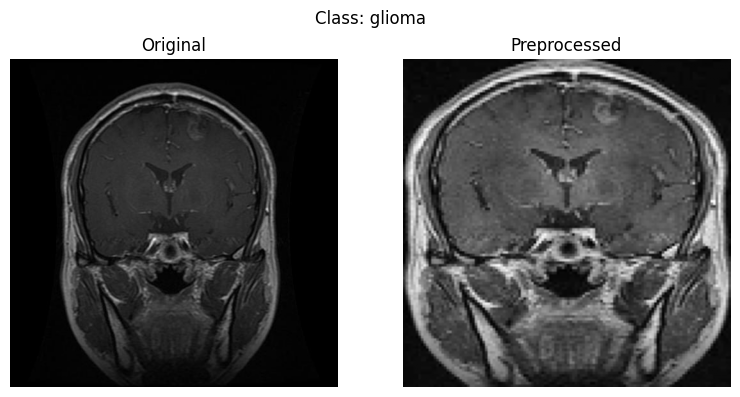

Loading meningioma:   0%|          | 0/1400 [00:00<?, ?it/s]

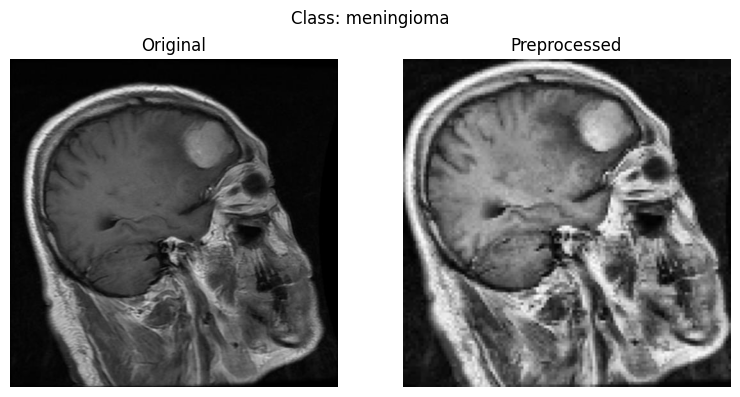

Loading notumor:   0%|          | 0/1400 [00:00<?, ?it/s]

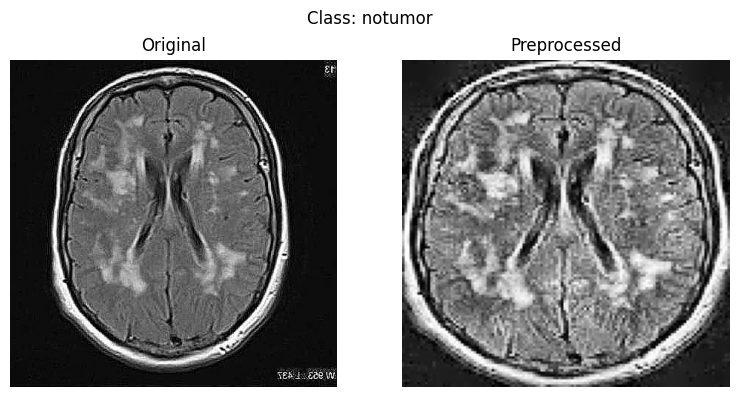

Loading pituitary:   0%|          | 0/1400 [00:00<?, ?it/s]

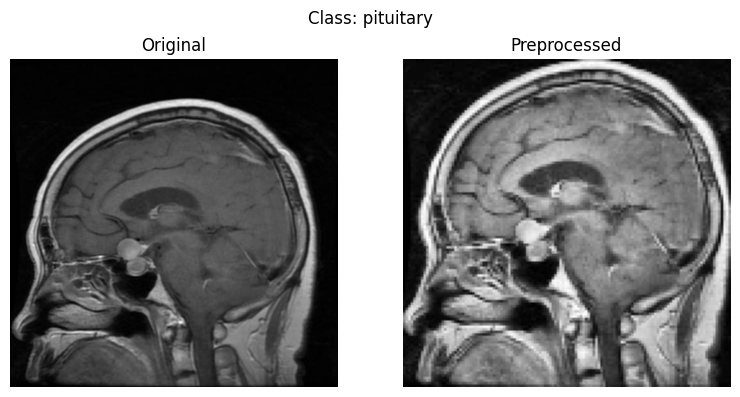

Loading pituitary: 100%|██████████| 1400/1400 [00:13<00:00, 100.61it/s]



Loading and preprocessing test data


Loading pituitary: 100%|██████████| 400/400 [00:10<00:00, 39.86it/s]


Train samples      : 3920
Validation samples : 1680
Test samples       : 1600

 - Generating augmented training data : 


Augmenting: 100%|██████████| 3920/3920 [00:02<00:00, 1678.00it/s]


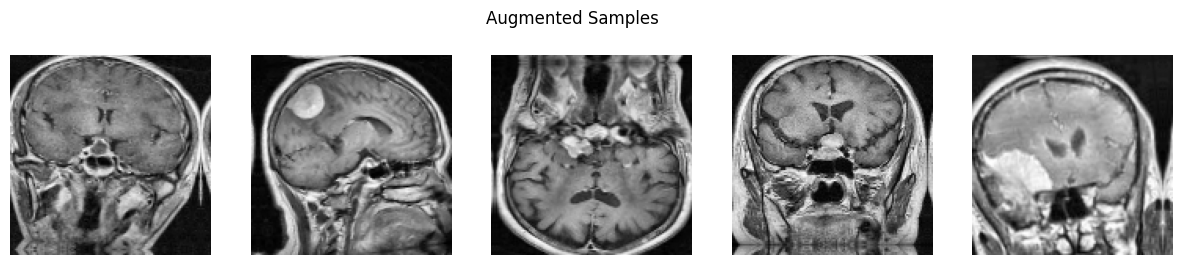


 - Summary :
X_train : (7840, 128, 128, 1)
X_val   : (1680, 128, 128, 1)
X_test  : (1600, 128, 128, 1)
Labels  : ['glioma', 'meningioma', 'notumor', 'pituitary']


In [ ]:
# Data augmentation functions
def augment_image(image):
    img = image.copy()  # (H, W, 1)

    # horizontal flip
    if np.random.rand() < 0.5:
        img = img[:, ::-1, :]

    h, w = img.shape[:2]

    # rotation
    angle = np.random.uniform(-10, 10)
    M = cv2.getRotationMatrix2D((w / 2, h / 2), angle, 1.0)

    img = cv2.warpAffine(
        img[:, :, 0],
        M,
        (w, h),
        flags=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_REFLECT_101
    )
    img = np.expand_dims(img, axis=-1)

    # shift
    shift_x = int(np.random.uniform(-0.05, 0.05) * w)
    shift_y = int(np.random.uniform(-0.05, 0.05) * h)

    M_shift = np.float32([[1, 0, shift_x], [0, 1, shift_y]])

    img = cv2.warpAffine(
        img[:, :, 0],
        M_shift,
        (w, h),
        flags=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_REFLECT_101
    )
    img = np.expand_dims(img, axis=-1)

    return img.astype(np.float32)


def augment_dataset(X, y, num_augmented_per_image=1):
    X_aug, y_aug = [], []

    for i in tqdm(range(len(X)), desc="Augmenting"):
        for _ in range(num_augmented_per_image):
            X_aug.append(augment_image(X[i]))
            y_aug.append(y[i])

    return np.array(X_aug, dtype=np.float32), np.array(y_aug)

print("Loading and preprocessing training data")
X_train_full, y_train_full = load_data(TRAIN_PATH, LABELS, plot=True)

print("\nLoading and preprocessing test data")
X_test, y_test = load_data(TEST_PATH, LABELS, plot=False)

# Split AFTER preprocessing
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.3,
    random_state=42,
    stratify=y_train_full
)

print(f"Train samples      : {X_train.shape[0]}")
print(f"Validation samples : {X_val.shape[0]}")
print(f"Test samples       : {X_test.shape[0]}")



# AUGMENTATION (train only)
print("\n - Generating augmented training data : ")
X_augmented, y_augmented = augment_dataset(X_train, y_train, num_augmented_per_image=1)



# Combine datasets
X_train_final = np.concatenate([X_train, X_augmented], axis=0)
y_train_final = np.concatenate([y_train, y_augmented], axis=0)

# Shuffle after concatenation
np.random.seed(SEED)
shuffle_idx = np.random.permutation(len(X_train_final))
X_train_final = X_train_final[shuffle_idx]
y_train_final = y_train_final[shuffle_idx]

# Show augmentation samples
indices = np.random.choice(len(X_augmented), 5, replace=False)



plt.figure(figsize=(15, 3))
for i, idx in enumerate(indices):
    plt.subplot(1, 5, i + 1)
    plt.imshow(X_augmented[idx].squeeze(), cmap='gray')
    plt.axis("off")

plt.suptitle("Augmented Samples")
plt.show()


# FINAL SUMMARY
print("\n - Summary :")
print(f"X_train : {X_train_final.shape}")
print(f"X_val   : {X_val.shape}")
print(f"X_test  : {X_test.shape}")
print(f"Labels  : {LABELS}")

**Why these transforms only**: Horizontal flipping, small rotations (±10°), and minor translations (±5%) simulate realistic variations in how patients are positioned during MRI scans. Aggressive transforms such as zoom, shear, or color jitter were intentionally excluded — they could distort clinically relevant brain structures and introduce unrealistic artifacts.


**Why we split after preprocessing**: Preprocessing is applied before splitting to ensure the validation and test sets go through the exact same pipeline as training data. Splitting first and preprocessing separately risks subtle inconsistencies between sets.

## 2.2 Label Encoding

Class names are text , neural networks only understand numbers.
We encode each class name as an integer using its position in the LABELS list.
The mapping is saved to label_map.json so teammates can decode model predictions back to class names.

| Class      | Encoded Label |
|------------|--------------|
| glioma     | 0            |
| meningioma | 1            |
| notumor    | 2            |
| pituitary  | 3            |

**Why integer encoding and not one-hot encoding**: The model will use sparse categorical cross-entropy as its loss function, which expects integer labels directly. One-hot encoding would require categorical cross-entropy instead and uses more memory — integer encoding is the cleaner choice here.

In [ ]:

# Label encoding map
label_map = {label: idx for idx, label in enumerate(LABELS)}

print("Label Encoding Map:")
for label, idx in label_map.items():
    print(f"  {label:15s} : {idx}")

# Save so teammates can decode predictions
with open(os.path.join(PROCESSED_PATH, "label_map.json"), "w") as f:
    json.dump(label_map, f, indent=4)

print("\nLabel map saved to processed/label_map.json")

Label Encoding Map:
  glioma          : 0
  meningioma      : 1
  notumor         : 2
  pituitary       : 3

Label map saved to processed/label_map.json


In [ ]:
np.save(os.path.join(PROCESSED_PATH, "X_train.npy"), X_train_final)
np.save(os.path.join(PROCESSED_PATH, "y_train.npy"), y_train_final)
np.save(os.path.join(PROCESSED_PATH, "X_val.npy"), X_val)
np.save(os.path.join(PROCESSED_PATH, "y_val.npy"), y_val)
np.save(os.path.join(PROCESSED_PATH, "X_test.npy"), X_test)
np.save(os.path.join(PROCESSED_PATH, "y_test.npy"), y_test)

### Setup


In [ ]:
import time
import shutil
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report, confusion_matrix
)

torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")

Device : cuda


## Configuration

All hyperparameters live in one dictionary so nothing is hardcoded inside the model or training functions. `BASELINE_CONFIG` is a deepcopy.


| Parameter | Value | Reason |
|---|---|---|
| Hidden layers | [512, 256, 128] | Pyramid shape — compresses the 16,384-dim input down gradually |
| Dropout | [0.3, 0.2, 0.2] | Heavier regularization earlier where the network is widest |
| Activation | Leaky ReLU | Prevents dying neurons that standard ReLU can produce |
| Batch size | 32 | Small enough to generalize, stable enough to train |
| Max epochs | 50 | Upper limit — early stopping will usually cut this short |
| LR | 0.001 | Adam's default, no reason to change before seeing results |
| Weight decay | 1e-4 | Light L2 penalty passed directly into the optimizer |
| Patience | 10 | Gives the model enough room to push through short plateaus before stopping |
| Scheduler factor | 0.5 | Halves the LR when triggered |
| Scheduler patience | 5 | Waits 5 epochs of no val loss improvement before halving LR |

In [ ]:
import copy

NUM_CLASSES = 4
INPUT_SIZE  = 128 * 128

CONFIG = {
    "hidden_sizes"      : [512, 256, 128],
    "dropout_rates"     : [0.3, 0.2, 0.2],
    "activation"        : "leaky_relu",


    "batch_size"        : 32,
    "epochs"            : 50,
    "lr"                : 0.001,
    "weight_decay"      : 1e-4,
    "patience"          : 10,


    "scheduler_factor"  : 0.5,
    "scheduler_patience": 5,
}


BASELINE_CONFIG = copy.deepcopy(CONFIG)
print("CONFIG ready.  BASELINE_CONFIG saved (deepcopy — safe to modify CONFIG freely).")
print(f"NUM_CLASSES={NUM_CLASSES}  INPUT_SIZE={INPUT_SIZE:,}")

CONFIG ready.  BASELINE_CONFIG saved (deepcopy — safe to modify CONFIG freely).
NUM_CLASSES=4  INPUT_SIZE=16,384


## Flattening & DataLoaders

FFNNs only accept 1D input — there's no concept of spatial structure. Each `(128×128×1)` image gets reshaped into a flat `(16384,)` vector before anything else. All spatial relationships between pixels are gone before the network even starts learning.

Two assertions run after flattening to catch silent errors: one checks the pixel range is still [0, 1] after reshaping.


DataLoaders wrap the tensors and handle batching. Training set is shuffled every epoch so the model doesn't memorize sample order. Validation and test are not shuffled — consistent ordering makes evaluation reproducible across runs.

In [ ]:
X_train_flat = X_train_final.reshape(X_train_final.shape[0], -1)
X_val_flat   = X_val.reshape(X_val.shape[0],   -1)
X_test_flat  = X_test.reshape(X_test.shape[0],  -1)

assert X_train_flat.max() <= 1.0 and X_train_flat.min() >= 0.0, "Pixel range error"
assert X_train_flat.dtype == np.float32, "dtype must be float32"
print(f"Shapes  →  train: {X_train_flat.shape}  val: {X_val_flat.shape}  test: {X_test_flat.shape}")
print(f"Range   →  [{X_train_flat.min():.3f}, {X_train_flat.max():.3f}]  dtype: {X_train_flat.dtype}")

def make_loader(X, y, batch_size, shuffle):
    ds = TensorDataset(torch.tensor(X, dtype=torch.float32),
                       torch.tensor(y, dtype=torch.long))
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle,
                      pin_memory=(DEVICE.type == "cuda"))

train_loader = make_loader(X_train_flat, y_train_final, CONFIG["batch_size"], shuffle=True)
val_loader   = make_loader(X_val_flat,   y_val,         CONFIG["batch_size"], shuffle=False)
test_loader  = make_loader(X_test_flat,  y_test,        CONFIG["batch_size"], shuffle=False)

print(f"\nLoaders →  train batches: {len(train_loader)}  "
      f"val batches: {len(val_loader)}  test batches: {len(test_loader)}")

Shapes  →  train: (7840, 16384)  val: (1680, 16384)  test: (1600, 16384)
Range   →  [0.004, 1.000]  dtype: float32

Loaders →  train batches: 245  val batches: 53  test batches: 50


## Model Architecture

The `FFNN` class takes `hidden_sizes` and `dropout_rates` as lists and builds the network dynamically — no layers are hardcoded.

Each hidden layer is the same repeating block:

Linear → BatchNorm1d → LeakyReLU → Dropout

The order here matters: BatchNorm comes before the activation so it normalizes the raw linear output first, giving the activation a consistent input range to work with. Dropout comes last, operating on already-activated values.

The output layer is `Linear(128 → 4)` with no activation. `CrossEntropyLoss` applies softmax internally — adding a separate softmax on top would be redundant and numerically less stable.

In [ ]:
def get_activation(name):
    name = name.lower()
    if name == "relu":
        return nn.ReLU()
    elif name == "leaky_relu":
        return nn.LeakyReLU(0.01)
    elif name == "elu":
        return nn.ELU()
    else:
        raise ValueError(f"Unknown activation '{name}'. Choose: relu | leaky_relu | elu")


class FFNN(nn.Module):

    def __init__(self, input_size, num_classes,
                 hidden_sizes=None,
                 dropout_rates=None,
                 activation="leaky_relu"):
        super().__init__()

        # Safe defaults — avoids Python's mutable default argument problem
        if hidden_sizes is None:
            hidden_sizes = [512, 256, 128]
        if dropout_rates is None:
            dropout_rates = [0.3, 0.2, 0.2]

        assert len(hidden_sizes) == len(dropout_rates),             "hidden_sizes and dropout_rates must have the same length"

        layers = []
        in_features = input_size
        for hidden, drop in zip(hidden_sizes, dropout_rates):
            layers += [
                nn.Linear(in_features, hidden),
                nn.BatchNorm1d(hidden),
                get_activation(activation),
                nn.Dropout(drop),
            ]
            in_features = hidden
        layers.append(nn.Linear(in_features, num_classes))  # output — no activation
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)


print("FFNN class and get_activation() ready.")

FFNN class and get_activation() ready.


## Architecture Choices — Ablation Results

Every design choice below was tested with a controlled experiment — same setup, one thing changed at a time. Baseline: **85.75% accuracy, F1: 0.8552**.

---

### Gradient clipping (max_norm = 1.0)

| Setting | Test Accuracy | F1 (macro) | Epochs Run | Best Val Loss |
|---|---|---|---|---|
| With clipping | 85.75% | 0.8552 | 23 | 0.3577 |
| Without clipping | 83.94% | 0.8350 | 31 | 0.3492 |

Without clipping the model ran 8 extra epochs and still came out 1.8% worse. Val loss was visibly noisier — large gradient updates were overshooting good minima instead of settling into them. With 16,384 features feeding into the first layer, dot products are large by construction, which makes this more of an issue here than in lower-dimensional networks.

---

### Batch normalization

| Setting | Test Accuracy | F1 (macro) | Epochs Run | Best Val Loss |
|---|---|---|---|---|
| With BatchNorm | 85.75% | 0.8552 | 23 | 0.3577 |
| Without BatchNorm | 70.12% | 0.6903 | 27 | 0.5867 |

Biggest drop of any experiment — 15.6% accuracy just from removing BatchNorm. Without it, val loss spiked to 1.2 in early epochs before slowly recovering. With 16,384 input features going into a 512-neuron first layer, activations drift badly between layers without normalization, making it very hard for later layers to learn anything consistent.

---

### Activation function

| Activation | Test Accuracy | F1 (macro) | Epochs Run | Best Val Loss |
|---|---|---|---|---|
| Leaky ReLU | 85.75% | 0.8552 | 23 | 0.3577 |
| ReLU | 81.50% | 0.8119 | 16 | 0.3524 |
| ELU | 73.94% | 0.7290 | 14 | 0.5107 |

ReLU stopped at epoch 16 — consistent with the dying neuron problem, where neurons that receive consistently negative inputs output zero forever and stop contributing to learning. Leaky ReLU avoids this by passing a small gradient (α=0.01) through even for negative values. ELU performed worst and stopped earliest — it likely needs its α tuned more carefully for this dataset.

---

### Weight decay (1e-4)

| Setting | Test Accuracy | F1 (macro) | Epochs Run | Best Val Loss |
|---|---|---|---|---|
| weight_decay = 1e-4 | 85.75% | 0.8552 | 23 | 0.3577 |
| weight_decay = 0.0 | 83.88% | 0.8374 | 19 | 0.3692 |

No weight decay converged faster (19 vs 23 epochs) but the train/val gap was slightly wider — a mild overfitting signal. Adding 1e-4 penalizes large weights and closes that gap by about 2%. The difference is small and only tested once, so this isn't a strong claim, but the direction is consistent with what L2 regularization is supposed to do.

---

### Loss function — CrossEntropyLoss

`CrossEntropyLoss` is the standard choice for multi-class classification — it combines `LogSoftmax` and `NLLLoss` into one numerically stable operation. The output layer produces raw logits with no activation, so adding softmax separately would be both redundant and less numerically stable.

---

### Optimizer — Adam (lr=0.001)

Adam's adaptive per-parameter learning rates handle high-dimensional sparse input well without much tuning. Weight decay is passed directly to Adam, so L2 regularization is applied through decoupled weight updates rather than manually penalizing the loss.

## Build & Inspect

`build_model()` reads from `CONFIG` and moves the model to the correct device. Wrapping this in a function rather than building inline means we can rebuild cleanly between trials with one line.

`print_config()` prints a full summary of whatever is currently in `CONFIG` — architecture, dropout, LR, scheduler settings, all of it. Useful for double-checking that the right settings are actually loaded before kicking off a long training run.

In [ ]:
def build_model(config):
    """Build FFNN from CONFIG dict and send to DEVICE."""
    model = FFNN(
        input_size    = INPUT_SIZE,
        num_classes   = NUM_CLASSES,
        hidden_sizes  = config["hidden_sizes"],
        dropout_rates = config["dropout_rates"],
        activation    = config["activation"],
    ).to(DEVICE)
    return model


def print_config(config):
    """Print a clean summary of the current experiment config."""
    arch = " → ".join(str(h) for h in config["hidden_sizes"])
    drops = config["dropout_rates"]
    print("=" * 60)
    print("  EXPERIMENT CONFIGURATION")
    print("=" * 60)
    print(f"  Architecture  : Input({INPUT_SIZE}) → {arch} → Output({NUM_CLASSES})")
    print(f"  Dropout rates : {drops}")
    print(f"  Activation    : {config['activation']}")
    print(f"  Batch size    : {config['batch_size']}")
    print(f"  Epochs (max)  : {config['epochs']}")
    print(f"  Learning rate : {config['lr']}")
    print(f"  Weight decay  : {config['weight_decay']}")
    print(f"  ES patience   : {config['patience']}")
    print(f"  Scheduler     : ReduceLROnPlateau  factor={config['scheduler_factor']}  "
          f"patience={config['scheduler_patience']}")
    print("=" * 60)


_m = build_model(CONFIG)
n_params = sum(p.numel() for p in _m.parameters() if p.requires_grad)
print_config(CONFIG)
print(f"\nTrainable parameters : {n_params:,}")
print(f"Approx. model size   : {n_params * 4 / 1e6:.2f} MB (float32)")
del _m

  EXPERIMENT CONFIGURATION
  Architecture  : Input(16384) → 512 → 256 → 128 → Output(4)
  Dropout rates : [0.3, 0.2, 0.2]
  Activation    : leaky_relu
  Batch size    : 32
  Epochs (max)  : 50
  Learning rate : 0.001
  Weight decay  : 0.0001
  ES patience   : 10
  Scheduler     : ReduceLROnPlateau  factor=0.5  patience=5

Trainable parameters : 8,555,652
Approx. model size   : 34.22 MB (float32)


## Training & Evaluation Functions

`train_one_epoch` and `evaluate` each handle one complete pass over the data:

- `train_one_epoch` — sets `model.train()` so dropout and BatchNorm behave correctly in training mode. For each batch: forward pass → compute loss → backward pass → clip gradients at `max_norm=1.0` → update weights.
- `evaluate` — sets `model.eval()` and wraps everything in `torch.no_grad()`. No gradients are computed and no weights change. Used for validation after every epoch and for the final test set evaluation.

The gradient clip in `train_one_epoch` is applied after `backward()` and before `optimizer.step()` — this is the correct position. Clipping after the step would have no effect.

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    """One full training pass. Returns (avg_loss, accuracy)."""
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss    = criterion(outputs, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * X_batch.size(0)
        correct    += (outputs.argmax(dim=1) == y_batch).sum().item()
        total      += X_batch.size(0)
    return total_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    """Evaluation pass (no weight updates). Returns (avg_loss, accuracy)."""
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs    = model(X_batch)
            loss       = criterion(outputs, y_batch)
            total_loss += loss.item() * X_batch.size(0)
            correct    += (outputs.argmax(dim=1) == y_batch).sum().item()
            total      += X_batch.size(0)
    return total_loss / total, correct / total


print("train_one_epoch() and evaluate() ready.")

train_one_epoch() and evaluate() ready.


## Early Stopping

Tracks validation loss after every epoch. If it doesn't improve by at least `min_delta=1e-4` for `patience=10` consecutive epochs, training halts and the best weights saved to disk are reloaded automatically.

Patience is set to 10 because brain MRI classification can have noisy validation loss — a plateau of 5 or 6 epochs doesn't necessarily mean the model is done improving. 10 gives it enough room to push through without waiting forever. The `min_delta` threshold filters out improvements so small they're basically noise.

Without early stopping, longer runs would tend to overfit as train loss keeps dropping while val loss starts climbing — and we'd have no way to recover the weights from before it started going wrong.

In [ ]:
class EarlyStopping:
    def __init__(self, patience=10, min_delta=1e-4, save_path="best_ffnn.pth"):
        self.patience      = patience
        self.min_delta     = min_delta
        self.save_path     = save_path
        self.best_loss     = float("inf")
        self.counter       = 0
        self.best_epoch    = 0
        self.stopped_epoch = None

    def step(self, val_loss, model, epoch):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss  = val_loss
            self.best_epoch = epoch
            self.counter    = 0
            torch.save(model.state_dict(), self.save_path)
            return False
        self.counter += 1
        if self.counter >= self.patience:
            self.stopped_epoch = epoch
            return True   # trigger stop
        return False


print("EarlyStopping class ready.")

EarlyStopping class ready.


## Full Training Pipeline

`train_ffnn()` runs a complete experiment from scratch. It resets all three seeds first (PyTorch CPU, PyTorch GPU, NumPy) so every trial is directly comparable. Then rebuilds the dataloaders in case `batch_size` changed, instantiates the model, optimizer, scheduler, and early stopping, and runs the full training loop.

The `ReduceLROnPlateau` scheduler monitors val loss and halves the LR (factor=0.5) if there's no improvement for 5 consecutive epochs. This gives the model a chance to fine-tune near a good minimum rather than oscillating around it.

After training, the best saved weights are loaded back before test evaluation — so the reported test numbers always correspond to the best validation epoch, not wherever training stopped. The function returns `history` (per-epoch loss/accuracy + LR), `timing_info` (test scores, speed, epoch count), and `results` (raw predictions for the confusion matrix).

In [ ]:
def train_ffnn(config, experiment_name="baseline", verbose=True):
    save_path = f"best_ffnn_{experiment_name}.pth"

    # ── Seed reset — ensures every experiment is fairly comparable ──
    torch.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    np.random.seed(SEED)

    if verbose:
        print(f"\n{'='*60}")
        print(f"  Experiment : {experiment_name}")
        print_config(config)

    # ── Rebuild loaders in case batch_size changed ──
    t_loader  = make_loader(X_train_flat, y_train_final, config["batch_size"], shuffle=True)
    v_loader  = make_loader(X_val_flat,   y_val,         config["batch_size"], shuffle=False)
    te_loader = make_loader(X_test_flat,  y_test,        config["batch_size"], shuffle=False)

    # ── Model, loss, optimizer, scheduler, early stopping ──
    model     = build_model(config)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(),
                           lr=config["lr"],
                           weight_decay=config["weight_decay"])
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode     = "min",
        factor   = config["scheduler_factor"],
        patience = config["scheduler_patience"],
    )
    es = EarlyStopping(patience=config["patience"], save_path=save_path)

    # ── History ──
    history = {"train_loss":[], "val_loss":[], "train_acc":[],
               "val_acc":[], "epoch_times":[], "lr_history":[]}
    early_stop_epoch = None
    training_start   = time.time()

    if verbose:
        print(f"\n{'Epoch':>6} | {'Train Loss':>10} | {'Train Acc':>9} | "
              f"{'Val Loss':>8} | {'Val Acc':>7} | {'LR':>8} | {'Time':>6}")
        print("-" * 72)

    for epoch in range(1, config["epochs"] + 1):
        t0 = time.time()
        train_loss, train_acc = train_one_epoch(model, t_loader, criterion, optimizer, DEVICE)
        val_loss,   val_acc   = evaluate(model, v_loader, criterion, DEVICE)
        epoch_time = time.time() - t0
        current_lr = optimizer.param_groups[0]["lr"]

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        history["epoch_times"].append(epoch_time)
        history["lr_history"].append(current_lr)

        if verbose:
            print(f"{epoch:>6} | {train_loss:>10.4f} | {train_acc:>9.4f} | "
                  f"{val_loss:>8.4f} | {val_acc:>7.4f} | {current_lr:>8.6f} | {epoch_time:>5.1f}s")

        scheduler.step(val_loss)
        if es.step(val_loss, model, epoch):
            early_stop_epoch = epoch
            if verbose:
                print(f"\n⚡ Early stopping at epoch {epoch} "
                      f"(best epoch: {es.best_epoch}, best val loss: {es.best_loss:.4f})")
            break

    total_time     = time.time() - training_start
    avg_epoch_time = sum(history["epoch_times"]) / len(history["epoch_times"])

    if verbose:
        print("-" * 72)
        print(f"Total time       : {total_time:.1f}s ({total_time/60:.1f} min)")
        print(f"Avg time / epoch : {avg_epoch_time:.2f}s | Epochs run: {len(history['train_loss'])}")

    # ── Load best weights ──
    model.load_state_dict(torch.load(save_path, map_location=DEVICE, weights_only=True))
    model.eval()

    # ── Inference on test set ──
    all_preds, all_labels = [], []
    infer_start = time.time()
    with torch.no_grad():
        for X_batch, y_batch in te_loader:
            outputs = model(X_batch.to(DEVICE))
            all_preds.extend(outputs.argmax(dim=1).cpu().numpy())
            all_labels.extend(y_batch.numpy())
    infer_time = time.time() - infer_start

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    test_acc        = accuracy_score(all_labels, all_preds)
    test_f1         = f1_score(all_labels, all_preds, average="macro")
    samples_per_sec = len(X_test_flat) / infer_time

    timing_info = {
        "experiment_name"         : experiment_name,
        "total_training_time_sec" : total_time,
        "avg_epoch_time_sec"      : avg_epoch_time,
        "epochs_run"              : len(history["train_loss"]),
        "early_stop_epoch"        : early_stop_epoch,
        "best_epoch"              : es.best_epoch,
        "inference_time_sec"      : infer_time,
        "samples_per_second"      : samples_per_sec,
        "test_accuracy"           : test_acc,
        "test_f1_macro"           : test_f1,
        "batch_size"              : config["batch_size"],
        "optimizer"               : "Adam",
        "learning_rate"           : config["lr"],
        "weight_decay"            : config["weight_decay"],
        "activation"              : config["activation"],
        "architecture"            : str([INPUT_SIZE] + config["hidden_sizes"] + [NUM_CLASSES]),
        "train_samples"           : X_train_flat.shape[0],
        "val_samples"             : X_val_flat.shape[0],
        "test_samples"            : X_test_flat.shape[0],
    }

    # ── Clean results dict ──
    results = {
        "all_preds"        : all_preds,
        "all_labels"       : all_labels,
        "early_stop_epoch" : early_stop_epoch,
        "best_epoch"       : es.best_epoch,
        "best_val_loss"    : es.best_loss,
    }

    if verbose:
        print(f"\nTest Accuracy   : {test_acc:.4f}  ({test_acc*100:.2f}%)")
        print(f"Test F1 (macro) : {test_f1:.4f}")
        print(f"Inference speed : {samples_per_sec:.0f} samples/sec")

    return model, history, timing_info, results


print("train_ffnn() ready.")

train_ffnn() ready.


## Training — Baseline

Running the baseline configuration. Loss and accuracy are logged each epoch for both train and validation. Early stopping is active with `patience=10` — training halts if val loss doesn't improve for 10 consecutive epochs and restores the best weights automatically.

In [ ]:
model, history, timing_info, results = train_ffnn(
    CONFIG,
    experiment_name="baseline",
    verbose=True
)

early_stop_epoch = results["early_stop_epoch"]


  Experiment : baseline
  EXPERIMENT CONFIGURATION
  Architecture  : Input(16384) → 512 → 256 → 128 → Output(4)
  Dropout rates : [0.3, 0.2, 0.2]
  Activation    : leaky_relu
  Batch size    : 32
  Epochs (max)  : 50
  Learning rate : 0.001
  Weight decay  : 0.0001
  ES patience   : 10
  Scheduler     : ReduceLROnPlateau  factor=0.5  patience=5

 Epoch | Train Loss | Train Acc | Val Loss | Val Acc |       LR |   Time
------------------------------------------------------------------------
     1 |     0.7260 |    0.7223 |   0.4911 |  0.8202 | 0.001000 |   3.0s
     2 |     0.4952 |    0.8166 |   0.5772 |  0.7857 | 0.001000 |   2.1s
     3 |     0.4000 |    0.8485 |   0.4296 |  0.8482 | 0.001000 |   1.8s
     4 |     0.3339 |    0.8786 |   0.5492 |  0.7982 | 0.001000 |   1.8s
     5 |     0.2796 |    0.8926 |   0.5387 |  0.8190 | 0.001000 |   1.8s
     6 |     0.2556 |    0.9040 |   0.4369 |  0.8619 | 0.001000 |   1.8s
     7 |     0.2312 |    0.9151 |   0.4141 |  0.8530 | 0.001000 |  

## Classification Report

Per-class precision, recall, and F1 on the test set. Overall accuracy can look fine while the model is quietly struggling on one specific class — for brain tumor classification that's not acceptable, so we check per-class performance alongside the overall number.

In [ ]:
print("Classification Report:")
print(classification_report(results["all_labels"], results["all_preds"], target_names=LABELS))

Classification Report:
              precision    recall  f1-score   support

      glioma       0.87      0.75      0.81       400
  meningioma       0.79      0.82      0.81       400
     notumor       0.93      0.97      0.95       400
   pituitary       0.90      0.94      0.92       400

    accuracy                           0.87      1600
   macro avg       0.87      0.87      0.87      1600
weighted avg       0.87      0.87      0.87      1600



## Confusion Matrix

Shows exactly which classes the model confuses with each other. Each row is the true label, each column is what the model predicted. The diagonal is correct predictions — off-diagonal cells are mistakes.

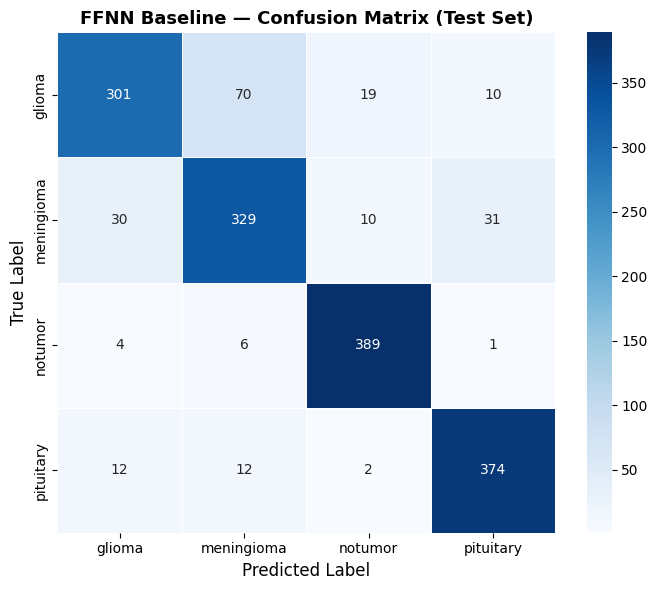

Saved: ffnn_confusion_matrix.png


In [ ]:
cm = confusion_matrix(results["all_labels"], results["all_preds"])
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=LABELS, yticklabels=LABELS,
            cmap="Blues", linewidths=0.5)
ax.set_xlabel("Predicted Label", fontsize=12)
ax.set_ylabel("True Label", fontsize=12)
ax.set_title("FFNN Baseline — Confusion Matrix (Test Set)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("ffnn_confusion_matrix.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: ffnn_confusion_matrix.png")

## Learning Curves

Train vs. validation loss and accuracy plotted per epoch. Two vertical lines are marked: the early stopping epoch (where training halted) and the best val loss epoch (the weights the model actually uses).

A healthy run shows both curves converging together. A growing gap between them — train loss falling while val loss flattens or rises — is the overfitting signal to watch for. Both curves staying high and flat would indicate underfitting. The size of the gap at convergence is the main thing to compare across trials.

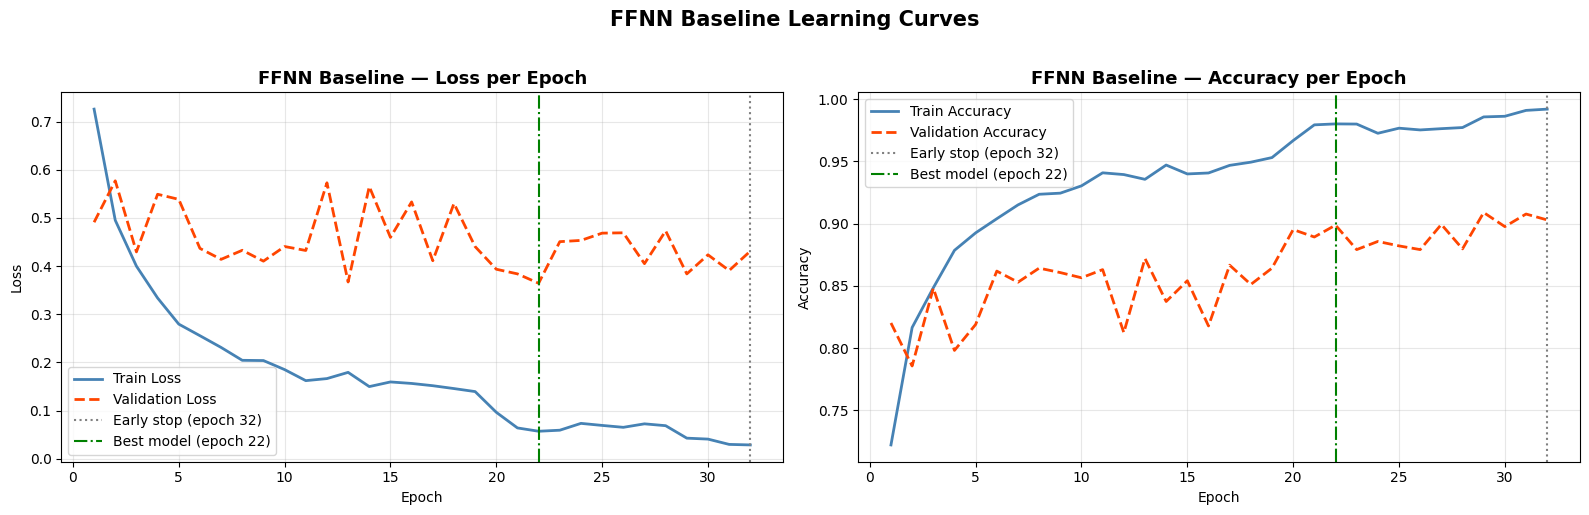

Saved: ffnn_baseline_learning_curves.png


In [ ]:
epochs_ran = range(1, len(history["train_loss"]) + 1)
fig, axes  = plt.subplots(1, 2, figsize=(16, 5))

for ax, metric, title, ylabel in [
    (axes[0], ("train_loss","val_loss"),  "Loss per Epoch",     "Loss"),
    (axes[1], ("train_acc", "val_acc"),   "Accuracy per Epoch", "Accuracy"),
]:
    ax.plot(epochs_ran, history[metric[0]], label=f"Train {ylabel}",     color="steelblue", linewidth=2)
    ax.plot(epochs_ran, history[metric[1]], label=f"Validation {ylabel}", color="orangered", linewidth=2, linestyle="--")
    if results["early_stop_epoch"]:
        ax.axvline(x=results["early_stop_epoch"], color="gray", linestyle=":", linewidth=1.5,
                   label=f"Early stop (epoch {results['early_stop_epoch']})")
    ax.axvline(x=results["best_epoch"], color="green", linestyle="-.", linewidth=1.5,
               label=f"Best model (epoch {results['best_epoch']})")
    ax.set_title(f"FFNN Baseline — {title}", fontsize=13, fontweight="bold")
    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle("FFNN Baseline Learning Curves", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("ffnn_baseline_learning_curves.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: ffnn_baseline_learning_curves.png")

## Saving Outputs

Saving history, timing info, baseline config, model weights, and plots to `ffnn_outputs`. This keeps everything organized and makes it easy to reload results later for the comparison section without retraining.

In [ ]:
OUTPUT_DIR = "ffnn_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Save numpy outputs ──
np.save(os.path.join(OUTPUT_DIR, "ffnn_history.npy"),    history)
np.save(os.path.join(OUTPUT_DIR, "ffnn_timing.npy"),     timing_info)
np.save(os.path.join(OUTPUT_DIR, "baseline_config.npy"), BASELINE_CONFIG)

# ── Save config as JSON (human-readable, no Python needed to open) ──
with open(os.path.join(OUTPUT_DIR, "baseline_config.json"), "w") as f:
    json.dump(BASELINE_CONFIG, f, indent=4)

# ── Copy plots and model weights ──
for fname in ["best_ffnn_baseline.pth",
              "ffnn_baseline_learning_curves.png",
              "ffnn_confusion_matrix.png"]:
    shutil.copy(fname, os.path.join(OUTPUT_DIR, fname))

print("Saved to ffnn_outputs/:")
for f in sorted(os.listdir(OUTPUT_DIR)):
    print(f"  {f}")

Saved to ffnn_outputs/:
  baseline_config.json
  baseline_config.npy
  best_ffnn_baseline.pth
  ffnn_baseline_learning_curves.png
  ffnn_confusion_matrix.png
  ffnn_history.npy
  ffnn_timing.npy


# FFNN Optimization

We take the baseline FFNN from Person 2 and tune it trial by trial.
Each trial changes one thing so we can clearly see what helped and what didn't



 #reset_config()

This function puts CONFIG back to its original default settings using a clean copy of BASELINE_CONFIG.
After resetting, it sets patience to 10 to override that one specific value.

In [ ]:
def reset_config():
    global CONFIG
    CONFIG = copy.deepcopy(BASELINE_CONFIG)
    CONFIG["patience"] = 10

reset_config()
print("CONFIG reset to baseline.")

In [ ]:
# Make the network wider
# that is because maybe the baseline doesn't have enough capacity to learn the patterns
reset_config()
CONFIG["hidden_sizes"]  = [1024, 512, 256, 128]
CONFIG["dropout_rates"] = [0.3, 0.2, 0.2, 0.2]

model_t1, history_t1, timing_t1, results_t1 = train_ffnn(
    CONFIG, experiment_name="trial1_wider", verbose=True
)
print(classification_report(results_t1["all_labels"], results_t1["all_preds"], target_names=LABELS))


  Experiment : trial1_wider
  EXPERIMENT CONFIGURATION
  Architecture  : Input(16384) → 1024 → 512 → 256 → 128 → Output(4)
  Dropout rates : [0.3, 0.2, 0.2, 0.2]
  Activation    : leaky_relu
  Batch size    : 32
  Epochs (max)  : 50
  Learning rate : 0.001
  Weight decay  : 0.0001
  ES patience   : 10
  Scheduler     : ReduceLROnPlateau  factor=0.5  patience=5

 Epoch | Train Loss | Train Acc | Val Loss | Val Acc |       LR |   Time
------------------------------------------------------------------------
     1 |     0.7384 |    0.7119 |   0.4915 |  0.8315 | 0.001000 |   2.9s
     2 |     0.5260 |    0.8056 |   0.8387 |  0.6732 | 0.001000 |   2.8s
     3 |     0.4354 |    0.8380 |   0.4088 |  0.8518 | 0.001000 |   2.8s
     4 |     0.3833 |    0.8606 |   0.6765 |  0.7512 | 0.001000 |   2.9s
     5 |     0.3243 |    0.8827 |   0.5338 |  0.8048 | 0.001000 |   3.1s
     6 |     0.3130 |    0.8869 |   0.5303 |  0.8244 | 0.001000 |   2.8s
     7 |     0.2642 |    0.9066 |   0.4672 |  0.838

# Trial 1 ( Wider Network)

This experiment resets the config and increases the network width by using more neurons per layer [1024, 512, 256, 128],
giving the model more capacity to learn complex patterns. It then trains the model and stores the results,
finally printing a full classification report to evaluate how well it performed.

# Trial 1 — Wider Network Conclusion

The bigger network didn't really help. It peaked very early at epoch 3 and then just got worse,
which means it was too big and started memorizing the data instead of learning from it.
It scored **79.06%** overall and had the most trouble telling apart `meningioma` from other types.

In [ ]:
# Add one more hidden layer (deeper network)
# more layers = more levels of abstraction
reset_config()
CONFIG["hidden_sizes"]  = [512, 256, 128, 64]
CONFIG["dropout_rates"] = [0.3, 0.2, 0.2, 0.1]

model_t2, history_t2, timing_t2, results_t2 = train_ffnn(
    CONFIG, experiment_name="trial2_deeper", verbose=True
)
print(classification_report(results_t2["all_labels"], results_t2["all_preds"], target_names=LABELS))


  Experiment : trial2_deeper
  EXPERIMENT CONFIGURATION
  Architecture  : Input(16384) → 512 → 256 → 128 → 64 → Output(4)
  Dropout rates : [0.3, 0.2, 0.2, 0.1]
  Activation    : leaky_relu
  Batch size    : 32
  Epochs (max)  : 50
  Learning rate : 0.001
  Weight decay  : 0.0001
  ES patience   : 10
  Scheduler     : ReduceLROnPlateau  factor=0.5  patience=5

 Epoch | Train Loss | Train Acc | Val Loss | Val Acc |       LR |   Time
------------------------------------------------------------------------
     1 |     0.7660 |    0.7094 |   0.6296 |  0.7458 | 0.001000 |   2.2s
     2 |     0.5240 |    0.8073 |   0.4367 |  0.8423 | 0.001000 |   2.2s
     3 |     0.4294 |    0.8430 |   1.2673 |  0.5685 | 0.001000 |   1.9s
     4 |     0.3623 |    0.8699 |   0.4330 |  0.8411 | 0.001000 |   1.9s
     5 |     0.3302 |    0.8802 |   0.5137 |  0.8250 | 0.001000 |   1.9s
     6 |     0.2831 |    0.8978 |   0.5082 |  0.8196 | 0.001000 |   1.9s
     7 |     0.2475 |    0.9107 |   0.4650 |  0.8470

# Trial 2  Deeper Network

This experiment resets the config and adds more hidden layers [512, 256, 128, 64] to help the model
learn more abstract patterns by processing data through extra levels. It trains the model and prints
a classification report to compare performance against the previous trial.

# Trial 2 — Deeper Network Conclusion

This one did much better, hitting **86.62% accuracy** which is a big jump from Trial 1.
The model ran for 42 epochs and took its time learning, which paid off across all 4 classes.
It was great at spotting notumor and pituitary but still had a little trouble with glioma,
so adding more layers was clearly a better idea than just making the network wider.

In [ ]:
# Lower the learning rate
# a smaller lr means more careful weight updates, can improve final accuracy
reset_config()
CONFIG["lr"] = 0.0005

model_t3, history_t3, timing_t3, results_t3 = train_ffnn(
    CONFIG, experiment_name="trial3_lower_lr", verbose=True
)
print(classification_report(results_t3["all_labels"], results_t3["all_preds"], target_names=LABELS))


  Experiment : trial3_lower_lr
  EXPERIMENT CONFIGURATION
  Architecture  : Input(16384) → 512 → 256 → 128 → Output(4)
  Dropout rates : [0.3, 0.2, 0.2]
  Activation    : leaky_relu
  Batch size    : 32
  Epochs (max)  : 50
  Learning rate : 0.0005
  Weight decay  : 0.0001
  ES patience   : 10
  Scheduler     : ReduceLROnPlateau  factor=0.5  patience=5

 Epoch | Train Loss | Train Acc | Val Loss | Val Acc |       LR |   Time
------------------------------------------------------------------------
     1 |     0.7316 |    0.7247 |   0.5651 |  0.7827 | 0.000500 |   2.0s
     2 |     0.4776 |    0.8260 |   0.5958 |  0.7804 | 0.000500 |   2.0s
     3 |     0.3615 |    0.8652 |   0.4134 |  0.8524 | 0.000500 |   1.8s
     4 |     0.2903 |    0.8944 |   0.5455 |  0.8179 | 0.000500 |   1.8s
     5 |     0.2318 |    0.9182 |   0.3588 |  0.8833 | 0.000500 |   1.8s
     6 |     0.2080 |    0.9247 |   0.4383 |  0.8637 | 0.000500 |   1.8s
     7 |     0.1852 |    0.9342 |   0.4941 |  0.8571 | 0.00

# Trial 3  Lower Learning Rate

This experiment resets the config and lowers the learning rate to 0.0005, making weight updates
smaller and more careful during training to potentially reach better accuracy. It then trains
and prints a classification report to check if the slower learning improved results.

# Trial 3  Lower Learning Rate Conclusion

This trial got **85.00% accuracy**, which is decent but not better than Trial 2.
The model peaked very early at epoch 5 and then stopped at epoch 15, meaning the slower
learning rate didn't really give it enough time to improve. It did great on notumor
but really struggled to correctly find glioma cases, missing about 38% of them.

In [ ]:
# Increase dropout rates
# if the model is overfitting, stronger dropout should help regularize it
reset_config()
CONFIG["dropout_rates"] = [0.5, 0.4, 0.3]

model_t4, history_t4, timing_t4, results_t4 = train_ffnn(
    CONFIG, experiment_name="trial4_high_dropout", verbose=True
)
print(classification_report(results_t4["all_labels"], results_t4["all_preds"], target_names=LABELS))


  Experiment : trial4_high_dropout
  EXPERIMENT CONFIGURATION
  Architecture  : Input(16384) → 512 → 256 → 128 → Output(4)
  Dropout rates : [0.5, 0.4, 0.3]
  Activation    : leaky_relu
  Batch size    : 32
  Epochs (max)  : 50
  Learning rate : 0.001
  Weight decay  : 0.0001
  ES patience   : 10
  Scheduler     : ReduceLROnPlateau  factor=0.5  patience=5

 Epoch | Train Loss | Train Acc | Val Loss | Val Acc |       LR |   Time
------------------------------------------------------------------------
     1 |     0.7959 |    0.6890 |   0.5971 |  0.7708 | 0.001000 |   2.1s
     2 |     0.5832 |    0.7838 |   0.7347 |  0.7167 | 0.001000 |   1.8s
     3 |     0.4997 |    0.8133 |   0.5175 |  0.8065 | 0.001000 |   1.8s
     4 |     0.4494 |    0.8364 |   0.4912 |  0.8119 | 0.001000 |   1.8s
     5 |     0.3913 |    0.8559 |   0.4931 |  0.8286 | 0.001000 |   1.8s
     6 |     0.3663 |    0.8647 |   0.4579 |  0.8488 | 0.001000 |   1.8s
     7 |     0.3413 |    0.8730 |   0.4624 |  0.8452 | 0

## Trial 4 — High Dropout

This experiment resets the config and increases dropout rates `[0.5, 0.4, 0.3]` to reduce overfitting
by randomly turning off more neurons during training, forcing the model to generalize better.
It then trains and prints a classification report to see if the regularization improved performance.

# Trial 4  High Dropout Conclusion

This trial also got **85.00% accuracy**, the same as Trial 3 but took much longer to get there,
running all the way to epoch 43. The higher dropout slowed the learning down a lot but didn't
really improve the final result, and it still struggled with glioma just like the other trials.
Overall, making dropout bigger didn't help enough to beat Trial 2.

In [ ]:
# Compare all trials
print(f"{'Trial':<25} {'Test Accuracy':>14}")
print("-" * 40)
print(f"{'Baseline':<25} {timing_info['test_accuracy']:>13.4f}")
print(f"{'Trial 1 - Wider':<25} {timing_t1['test_accuracy']:>13.4f}")
print(f"{'Trial 2 - Deeper':<25} {timing_t2['test_accuracy']:>13.4f}")
print(f"{'Trial 3 - Lower LR':<25} {timing_t3['test_accuracy']:>13.4f}")
print(f"{'Trial 4 - High Dropout':<25} {timing_t4['test_accuracy']:>13.4f}")

Trial                      Test Accuracy
----------------------------------------
Baseline                         0.8706
Trial 1 - Wider                  0.7906
Trial 2 - Deeper                 0.8662
Trial 3 - Lower LR               0.8500
Trial 4 - High Dropout           0.8500


# Comparing All Trials

This block prints a formatted table that lines up each trial name with its test accuracy score.
It pulls the accuracy from each trial's timing info and displays them together for easy comparison.

In [ ]:
# Based on the summary above, pick the best trial and retrain it as the final model
# Change the config below to match whichever trial won
reset_config()
CONFIG["hidden_sizes"]  = [512, 256, 128, 64]   # change this to the winning trial's values
CONFIG["dropout_rates"] = [0.3, 0.2, 0.2, 0.1]  # change this to the winning trial's values
# CONFIG["lr"] = ...                             # uncomment and change if lr trial won

model_best, history_best, timing_best, results_best = train_ffnn(
    CONFIG, experiment_name="ffnn_best", verbose=True
)
print(classification_report(results_best["all_labels"], results_best["all_preds"], target_names=LABELS))


  Experiment : ffnn_best
  EXPERIMENT CONFIGURATION
  Architecture  : Input(16384) → 512 → 256 → 128 → 64 → Output(4)
  Dropout rates : [0.3, 0.2, 0.2, 0.1]
  Activation    : leaky_relu
  Batch size    : 32
  Epochs (max)  : 50
  Learning rate : 0.001
  Weight decay  : 0.0001
  ES patience   : 10
  Scheduler     : ReduceLROnPlateau  factor=0.5  patience=5

 Epoch | Train Loss | Train Acc | Val Loss | Val Acc |       LR |   Time
------------------------------------------------------------------------
     1 |     0.7660 |    0.7094 |   0.6296 |  0.7458 | 0.001000 |   2.2s
     2 |     0.5240 |    0.8073 |   0.4367 |  0.8423 | 0.001000 |   2.0s
     3 |     0.4294 |    0.8430 |   1.2673 |  0.5685 | 0.001000 |   2.0s
     4 |     0.3623 |    0.8699 |   0.4330 |  0.8411 | 0.001000 |   2.0s
     5 |     0.3302 |    0.8802 |   0.5137 |  0.8250 | 0.001000 |   1.9s
     6 |     0.2831 |    0.8978 |   0.5082 |  0.8196 | 0.001000 |   1.9s
     7 |     0.2475 |    0.9107 |   0.4650 |  0.8470 | 0

# Final Model — Best Trial

This block resets the config and manually applies the winning trial's settings for hidden_sizes
and dropout_rates based on the comparison table above. It then retrains the model one final
time under the name ffnn_best and prints the classification report as the definitive result.

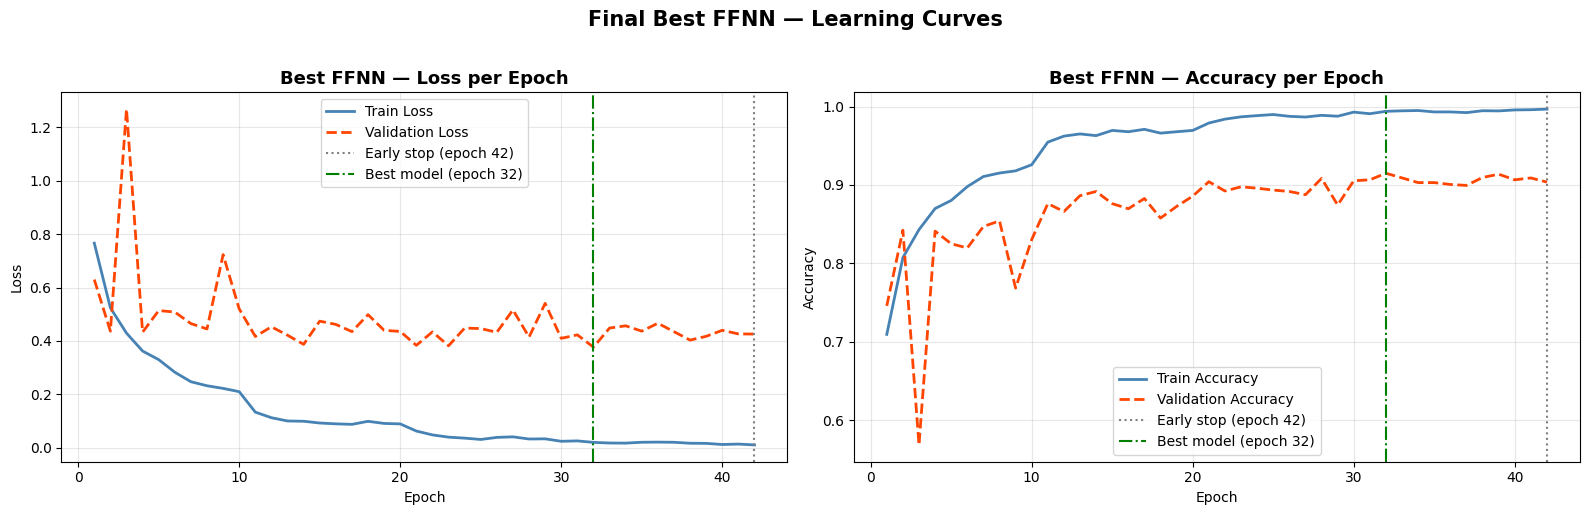

Saved: ffnn_best_learning_curves.png


In [ ]:
# Final learning curves for the best FFNN model
epochs_ran = range(1, len(history_best["train_loss"]) + 1)
fig, axes  = plt.subplots(1, 2, figsize=(16, 5))

for ax, metric, title, ylabel in [
    (axes[0], ("train_loss", "val_loss"), "Loss per Epoch",     "Loss"),
    (axes[1], ("train_acc",  "val_acc"),  "Accuracy per Epoch", "Accuracy"),
]:
    ax.plot(epochs_ran, history_best[metric[0]], label=f"Train {ylabel}",      color="steelblue", linewidth=2)
    ax.plot(epochs_ran, history_best[metric[1]], label=f"Validation {ylabel}", color="orangered", linewidth=2, linestyle="--")
    if results_best["early_stop_epoch"]:
        ax.axvline(x=results_best["early_stop_epoch"], color="gray", linestyle=":", linewidth=1.5,
                   label=f"Early stop (epoch {results_best['early_stop_epoch']})")
    ax.axvline(x=results_best["best_epoch"], color="green", linestyle="-.", linewidth=1.5,
               label=f"Best model (epoch {results_best['best_epoch']})")
    ax.set_title(f"Best FFNN — {title}", fontsize=13, fontweight="bold")
    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle("Final Best FFNN — Learning Curves", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("ffnn_best_learning_curves.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: ffnn_best_learning_curves.png")

# Final Learning Curves  Best FFNN

This block plots two side-by-side graphs showing how the best model's loss and accuracy changed
across each epoch for both training and validation, with markers for when early stopping triggered
and when the best model checkpoint was reached. The final figure is saved as ffnn_best_learning_curves.png.

# Comparing All Trials

**Trial 1 — Wider Network — 79.06%**
We made the network bigger by adding more neurons. It stopped learning very early
and was the worst out of all trials. Making it wider did not help.

**Trial 2 — Deeper Network — 86.62% **
We added more layers instead. This was the best trial by far. The model took
its time learning and did well across all classes.

**Trial 3 — Lower Learning Rate — 85.00%**
We slowed down how fast the model learns. It did okay but peaked too early
and never really got better after that.

**Trial 4 — High Dropout — 85.00%**
We turned off more neurons during training to stop overfitting. It ran for
a long time but ended up with the same score as Trial 3, so it didn't help much.



The best is clearly **Trial 2** with **86.62%**. Adding more layers
worked better than any other change we tried.

## CNN Architecture & Implementation

This section builds a Convolutional Neural Network (CNN) on the MRI brain tumour dataset

**Contents:**
1. Imports
2. Load preprocessed data & DataLoaders
3. Tensor dimension walkthrough
4. CNN model definition
5. Early Stopping
6. Training loop
7. Run training
8. Learning curves
9. Test evaluation & inference speed
10. Save results


In [ ]:
import sys
!{sys.executable} -m pip install torch torchvision tqdm seaborn scikit-learn --quiet

### 1. Imports

PyTorch (`torch.nn`, `torch.optim`) provides all layer types, optimizers, and loss functions needed. `sklearn.metrics` handles evaluation. `copy` is used by Early Stopping to snapshot the best model weights during training.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
import time, os, copy, json

from sklearn.metrics import (accuracy_score, f1_score,
                             classification_report, confusion_matrix)
import seaborn as sns
from tqdm import tqdm

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")

Device : cuda


### 2. Load Preprocessed Data & DataLoaders

**Tensor dimension convention:**
PyTorch expects images as `(N, C, H, W)` — batch(no of samples or images), channels, height, width.  images saved as `(N, H, W, C)` (NumPy convention), so `.permute(0, 3, 1, 2)` reorders the axes before training.

**DataLoader:**
Wraps the tensor dataset and handles batching and shuffling automatically. Training data is shuffled every epoch to prevent the model from learning the order of samples. Validation and test are never shuffled — consistent order ensures reproducible evaluation.

**Hyperparameters are matched with FFNN:**
Batch size (32), max epochs (50), learning rate (0.001), and optimizer (Adam) are identical across both models to ensure a fair architectural comparison.

In [ ]:
PROCESSED_PATH = os.path.join("output", "processed")
CNN_OUT        = os.path.join("output", "cnn_results")
os.makedirs(CNN_OUT, exist_ok=True)

X_train = np.load(os.path.join(PROCESSED_PATH, "X_train.npy"))
y_train = np.load(os.path.join(PROCESSED_PATH, "y_train.npy"))
X_val   = np.load(os.path.join(PROCESSED_PATH, "X_val.npy"))
y_val   = np.load(os.path.join(PROCESSED_PATH, "y_val.npy"))
X_test  = np.load(os.path.join(PROCESSED_PATH, "X_test.npy"))
y_test  = np.load(os.path.join(PROCESSED_PATH, "y_test.npy"))

print("Loaded shapes (NumPy — H W C):")
print(f"  X_train: {X_train.shape}  y_train: {y_train.shape}")
print(f"  X_val  : {X_val.shape}  y_val  : {y_val.shape}")
print(f"  X_test : {X_test.shape}  y_test : {y_test.shape}")

#  Derive dimensions automatically
N, H, W, C   = X_train.shape
NUM_CLASSES  = len(np.unique(y_train))
CLASS_NAMES  = ['glioma', 'meningioma', 'notumor', 'pituitary']

print(f"\nImage size : {H} x {W}  |  Channels : {C}  |  Classes : {NUM_CLASSES}")

#  Convert NumPy to PyTorch tensors, fix channel order
def make_tensors(X, y):
    # (N, H, W, C) to (N, C, H, W)
    X_t = torch.tensor(X, dtype=torch.float32).permute(0, 3, 1, 2)
    y_t = torch.tensor(y, dtype=torch.long)
    return X_t, y_t

X_train_t, y_train_t = make_tensors(X_train, y_train)
X_val_t,   y_val_t   = make_tensors(X_val,   y_val)
X_test_t,  y_test_t  = make_tensors(X_test,  y_test)

print(f"\nPyTorch tensor shape (N, C, H, W): {tuple(X_train_t.shape)}")

BATCH_SIZE    = 32
NUM_EPOCHS    = 50
LEARNING_RATE = 0.001

# DataLoaders
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t),
                          batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val_t,   y_val_t),
                          batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(TensorDataset(X_test_t,  y_test_t),
                          batch_size=BATCH_SIZE, shuffle=False)

print(f"\nBatch size      : {BATCH_SIZE}")
print(f"Training batches: {len(train_loader)}")
print(f"Val batches     : {len(val_loader)}")
print(f"Test batches    : {len(test_loader)}")

Loaded shapes (NumPy — H W C):
  X_train: (7840, 128, 128, 1)  y_train: (7840,)
  X_val  : (1680, 128, 128, 1)  y_val  : (1680,)
  X_test : (1600, 128, 128, 1)  y_test : (1600,)

Image size : 128 x 128  |  Channels : 1  |  Classes : 4

PyTorch tensor shape (N, C, H, W): (7840, 1, 128, 128)

Batch size      : 32
Training batches: 245
Val batches     : 53
Test batches    : 50


## 3. Tensor Dimension Walkthrough

Before building the full model, we trace the exact tensor shape at every layer for the baseline architecture (3 convolutional blocks with filter_list=[32, 64, 128]).

This step is critical because the first `Linear` layer in the FC head must receive exactly the right number of inputs — a shape mismatch causes a runtime crash.

Rather than computing the flatten size manually, we run a **dummy forward pass** with a zero tensor through the conv blocks and read the output shape directly. This approach is robust — if any layer changes, the flatten size updates automatically.

**Data flow through the 3 blocks for baseline:**

| Stage | Operation | Output Shape |
|---|---|---|
| Input | — | (1, 1, 128, 128) |
| After Conv Block 1 | Conv(32) + BN + ReLU + MaxPool | (1, 32, 64, 64) |
| After Conv Block 2 | Conv(64) + BN + ReLU + MaxPool | (1, 64, 32, 32) |
| After Conv Block 3 | Conv(128) + BN + ReLU + MaxPool | (1, 128, 16, 16) |
| After Flatten | — | (1, 32768) |

Each MaxPool2d(2) halves the spatial dimensions (H and W). After 3 pooling operations the image shrinks from 128×128 down to 16×16. With 128 filters that gives 128 × 16 × 16 = **32,768** — the value that goes into the first Linear layer.

In [ ]:
#  Dummy pass to compute flatten size automatically
# We build just the conv part first, pass a zero tensor through it, then read the output shape — no manual formula needed.

_dummy_conv = nn.Sequential(
    # Block 1
    nn.Conv2d(C,  32, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2),
    # Block 2
    nn.Conv2d(32, 64, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2),
    # Block 3
    nn.Conv2d(64, 128, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2),
)

with torch.no_grad():  #No training : faster + less memory
    _x = torch.zeros(1, C, H, W)
    print(f"Input          : {tuple(_x.shape)}")

    _x = _dummy_conv[0](_x)               # Conv block 1 — conv
    print(f"After conv1    : {tuple(_x.shape)}")
    _x = _dummy_conv[1](_x)               # ReLU
    _x = _dummy_conv[2](_x)               # MaxPool
    print(f"After pool1    : {tuple(_x.shape)}")

    _x = _dummy_conv[3](_x)               # Conv block 2 — conv
    print(f"After conv2    : {tuple(_x.shape)}")
    _x = _dummy_conv[4](_x)
    _x = _dummy_conv[5](_x)               # MaxPool
    print(f"After pool2    : {tuple(_x.shape)}")

    _x = _dummy_conv[6](_x)               # Conv block 3 — conv
    print(f"After conv3    : {tuple(_x.shape)}")
    _x = _dummy_conv[7](_x)
    _x = _dummy_conv[8](_x)               # MaxPool
    print(f"After pool3    : {tuple(_x.shape)}")

    FLATTEN_SIZE = _x.view(1, -1).shape[1] #To flatten into a vector
    print(f"After flatten  : {FLATTEN_SIZE}  : this goes into Linear()")

del _dummy_conv, _x

Input          : (1, 1, 128, 128)
After conv1    : (1, 32, 128, 128)
After pool1    : (1, 32, 64, 64)
After conv2    : (1, 64, 64, 64)
After pool2    : (1, 64, 32, 32)
After conv3    : (1, 128, 32, 32)
After pool3    : (1, 128, 16, 16)
After flatten  : 32768  : this goes into Linear()


## 4. CNN Model Definition

### Architecture Overview

The CNN consists of convolutional blocks for feature extraction followed by a fully connected head for classification. All dimensions are derived from the data — nothing is hardcoded.

The convolutional blocks are built **dynamically using a loop** over `filter_list`. Each entry in `filter_list` produces one complete conv block — meaning the number of blocks, filter counts, kernel size, and pooling strategy can all be changed by passing different arguments. This makes the same class reusable for both the baseline and all optimization trials.

### Baseline Configuration

```python
CNN(in_channels=C, num_classes=NUM_CLASSES, flatten_size=FLATTEN_SIZE)
# filter_list defaults to [32, 64, 128] → 3 blocks
```

### What Each Block Contains

Each iteration of the loop produces:
`Conv2d → BatchNorm2d → ReLU → MaxPool2d → Dropout2d`

### Design Choices — Justified

**filter_list=[32, 64, 128] — 3 blocks:**
Filter count doubles each block. Early layers detect simple patterns (edges, boundaries) and need fewer filters. Deeper layers detect complex tumour structures and need more. 3 blocks is the standard choice for 128×128 images — enough depth without over-compressing spatial information.

**kernel_size=3, padding=kernel_size//2:**
3×3 is the standard kernel size — captures local patterns efficiently. padding=kernel//2 preserves spatial dimensions after convolution so MaxPool is the only operation that reduces size. This formula also automatically handles kernel_size=5 in optimization trials.

**BatchNorm after every Conv:**
Normalises activations between layers, stabilises training, and reduces sensitivity to learning rate — especially important on CPU where training is slow.

**MaxPool2d(2):**
Halves spatial dimensions after each block (128→64→32→16), reduces computation, and makes the model tolerant to small shifts in tumour position.

**ReLU:**
Standard activation for CNNs. Avoids vanishing gradients and is computationally cheap.

**Dropout2d(0.25) in conv blocks:**
Drops entire feature maps during training, preventing reliance on any single detected feature. Dropout2d is used instead of regular Dropout because conv outputs are 2D feature maps not flat vectors.

**FC head — Linear(flatten_size→512) → Linear(512→NUM_CLASSES):**
Compresses extracted features into 512 key signals then maps to class scores. Raw logits are output — CrossEntropyLoss applies softmax internally.

**Dropout(0.5) in FC head:**
Higher than conv blocks because the FC layer has far more parameters and is more prone to memorisation.

In [ ]:
class CNN(nn.Module):
    def __init__(self, in_channels, num_classes, flatten_size,
                 filter_list=None, kernel_size=3,
                 pooling="max", fc_neurons=512):
        """
        Parameters are passed in so the model
        adapts automatically to different datasets.

        in_channels  : number of image channels (1 = grayscale, 3 = RGB)
        num_classes  : number of output classes
        flatten_size : computed from the dummy pass cell above
        filter_list  : list of filter counts per block e.g. [32,64,128]
        kernel_size  : conv kernel size (3 or 5)
        pooling      : "max" for MaxPool2d, "avg" for AvgPool2d
        fc_neurons   : number of neurons in the FC hidden layer
        """
        if filter_list is None:
            filter_list = [32, 64, 128]

        super(CNN, self).__init__()

        layers = []
        ch = in_channels
        for filters in filter_list:
            layers += [
                nn.Conv2d(ch, filters, kernel_size=kernel_size, padding=kernel_size//2),
                nn.BatchNorm2d(filters),
                nn.ReLU(),
                nn.MaxPool2d(kernel_size=2) if pooling == "max" else nn.AvgPool2d(kernel_size=2),
                nn.Dropout2d(0.25)
            ]
            ch = filters
        self.conv_blocks = nn.Sequential(*layers)

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flatten_size, fc_neurons),
            nn.BatchNorm1d(fc_neurons),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(fc_neurons, num_classes)
        )

    def forward(self, x):
        x = self.conv_blocks(x)
        x = self.classifier(x)
        return x


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNN(in_channels  = C,
            num_classes  = NUM_CLASSES,
            flatten_size = FLATTEN_SIZE).to(device)

print(model)
print()
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {total_params:,}")

CNN(
  (conv_blocks): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout2d(p=0.25, inplace=False)
    (5): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Dropout2d(p=0.25, inplace=False)
    (10): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU()
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Dropout2d(p=0.25, inplace=False)
  )
  (classifier): Sequential(
    (0): F

### 5. Early Stopping

Monitors validation loss after every epoch and halts training if no improvement occurs for `patience` consecutive epochs. The best model weights — from the epoch with the lowest validation loss — are automatically restored at the end.

**Why patience = 7:**
Brain MRI classification is a complex 4-class problem and validation loss can fluctuate for several epochs before improving again. Patience of 7 gives the model enough room to push through short plateaus without triggering early stopping prematurely, while avoiding unnecessary extra training time on CPU.

*Overfitting concern:*
To counter the risk that comes with allowing more training epochs, we use Dropout(0.25) in the convolutional blocks and Dropout(0.5) in the FC head, along with BatchNorm after every layer. These act as the primary defence against overfitting, so patience=7 strikes the right balance between convergence and generalisation.

In [ ]:
class EarlyStoppingCNN:
    def __init__(self, patience=7, min_delta=0.001):
        self.patience      = patience
        self.min_delta     = min_delta
        self.counter       = 0
        self.best_loss     = None
        self.best_weights  = None
        self.stopped_epoch = None
        self.early_stop    = False

    def __call__(self, val_loss, model, epoch):
        if self.best_loss is None:
            self.best_loss    = val_loss
            self.best_weights = copy.deepcopy(model.state_dict())

        elif val_loss < self.best_loss - self.min_delta:
            # Improvement — reset counter, snapshot weights
            self.best_loss    = val_loss
            self.best_weights = copy.deepcopy(model.state_dict())
            self.counter      = 0

        else:
            self.counter += 1
            print(f"   EarlyStopping: {self.counter}/{self.patience} epochs without improvement")
            if self.counter >= self.patience:
                self.early_stop    = True
                self.stopped_epoch = epoch
                print(f"   *** Early stopping triggered at epoch {epoch} ***")

    def restore_best_weights(self, model):
        model.load_state_dict(self.best_weights)
        print("   Best weights restored.")

print("EarlyStopping defined — patience=7, min_delta=0.001")

EarlyStopping defined — patience=7, min_delta=0.001


### 6. Training Loop

Each epoch has two phases:

**Training phase** (`model.train()`):
Dropout and BatchNorm behave in training mode.
For every batch: forward pass - compute loss - backward pass - update weights.

**Validation phase** (`model.eval()` + `torch.no_grad()`):
No gradient computation. No weight updates. Just measure how well the model
generalises to data it has never trained on.

Both phases record loss and accuracy per epoch for the learning curves.

In [ ]:
def run_epoch(model, loader, criterion, optimizer, is_training):
    """
    Runs one full pass (train or val) over `loader`.
    Returns average loss and accuracy for that pass.
    """
    if is_training:
        model.train()
    else:
        model.eval()

    total_loss, correct, total = 0.0, 0, 0

    ctx = torch.enable_grad() if is_training else torch.no_grad()
    with ctx:
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            if is_training:
                optimizer.zero_grad()

            outputs = model(X_batch)
            loss    = criterion(outputs, y_batch)

            if is_training:
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * X_batch.size(0)
            preds       = outputs.argmax(dim=1)
            correct    += (preds == y_batch).sum().item()
            total      += y_batch.size(0)

    return total_loss / total, correct / total


def train_model(model, train_loader, val_loader,
                optimizer, criterion, num_epochs, early_stopping):
    """
    Full training loop.
    Returns arrays of train/val loss and accuracy, epoch times,
    and the epoch at which early stopping triggered (or None).
    """
    train_losses, val_losses = [], []
    train_accs,   val_accs   = [], []
    epoch_times              = []

    for epoch in range(1, num_epochs + 1):
        t0 = time.time()

        train_loss, train_acc = run_epoch(model, train_loader,
                                          criterion, optimizer, is_training=True)
        val_loss,   val_acc   = run_epoch(model, val_loader,
                                          criterion, optimizer, is_training=False)

        elapsed = time.time() - t0
        train_losses.append(train_loss);  val_losses.append(val_loss)
        train_accs.append(train_acc);     val_accs.append(val_acc)
        epoch_times.append(elapsed)

        print(f"Epoch [{epoch:02d}/{num_epochs}] "
              f"| Train Loss: {train_loss:.4f}  Acc: {train_acc:.4f} "
              f"| Val Loss: {val_loss:.4f}  Acc: {val_acc:.4f} "
              f"| {elapsed:.1f}s")

        early_stopping(val_loss, model, epoch)
        if early_stopping.early_stop:
            break

    early_stopping.restore_best_weights(model)

    return (np.array(train_losses), np.array(val_losses),
            np.array(train_accs),   np.array(val_accs),
            np.array(epoch_times),  early_stopping.stopped_epoch)

print("Training functions defined.")

Training functions defined.


### 7. Run Training

**Optimizer — Adam (lr=0.001):**
Adam adapts the learning rate individually for each parameter using first and second moment estimates. It converges faster than SGD on image classification without requiring extensive learning rate tuning.

**Loss — CrossEntropyLoss:**
The correct loss for multi-class classification. Combines log-softmax and negative log-likelihood internally — the model outputs raw logits and the loss handles the rest.

**Settings matched with (FFNN)** — batch size, epochs, learning rate, and optimizer are identical to ensure a fair comparison.

In [ ]:
# Re-instantiate fresh model and optimizer
model          = CNN(in_channels  = C,
                     num_classes  = NUM_CLASSES,
                     flatten_size = FLATTEN_SIZE).to(device)
optimizer      = optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion      = nn.CrossEntropyLoss()
early_stopping = EarlyStoppingCNN(patience=7, min_delta=0.001)

print("=" * 72)
print("CNN Training — Baseline")
print(f"  Device        : {device}")
print(f"  Image size    : {H} x {W} x {C}")
print(f"  Classes       : {NUM_CLASSES}  {CLASS_NAMES}")
print(f"  Batch size    : {BATCH_SIZE}")
print(f"  Max epochs    : {NUM_EPOCHS}")
print(f"  Learning rate : {LEARNING_RATE}  (Optimizer: Adam)")
print(f"  Loss function : CrossEntropyLoss")
print("=" * 72)

total_start = time.time()

(train_losses, val_losses,
 train_accs,   val_accs,
 epoch_times,  stopped_epoch) = train_model(
    model, train_loader, val_loader,
    optimizer, criterion, NUM_EPOCHS, early_stopping
)

total_time     = time.time() - total_start
avg_epoch_time = epoch_times.mean()
epochs_run     = len(train_losses)

print()
print("=" * 72)
print(f"Training complete.")
print(f"  Epochs run          : {epochs_run}")
print(f"  Early stop epoch    : {stopped_epoch if stopped_epoch else 'N/A (all epochs ran)'}")
print(f"  Total training time : {total_time:.1f}s")
print(f"  Avg per-epoch time  : {avg_epoch_time:.2f}s")
print(f"  Best val loss       : {val_losses.min():.4f}  (epoch {val_losses.argmin()+1})")
print(f"  Best val accuracy   : {val_accs.max():.4f}  (epoch {val_accs.argmax()+1})")
print("=" * 72)

CNN Training — Baseline
  Device        : cuda
  Image size    : 128 x 128 x 1
  Classes       : 4  ['glioma', 'meningioma', 'notumor', 'pituitary']
  Batch size    : 32
  Max epochs    : 50
  Learning rate : 0.001  (Optimizer: Adam)
  Loss function : CrossEntropyLoss
Epoch [01/50] | Train Loss: 0.7954  Acc: 0.6823 | Val Loss: 0.4417  Acc: 0.8387 | 8.0s
Epoch [02/50] | Train Loss: 0.5360  Acc: 0.7968 | Val Loss: 0.3388  Acc: 0.8756 | 7.3s
Epoch [03/50] | Train Loss: 0.4241  Acc: 0.8383 | Val Loss: 0.2820  Acc: 0.9024 | 7.3s
Epoch [04/50] | Train Loss: 0.3720  Acc: 0.8606 | Val Loss: 0.2973  Acc: 0.8893 | 7.4s
   EarlyStopping: 1/7 epochs without improvement
Epoch [05/50] | Train Loss: 0.3266  Acc: 0.8776 | Val Loss: 0.2322  Acc: 0.9113 | 7.4s
Epoch [06/50] | Train Loss: 0.2551  Acc: 0.9042 | Val Loss: 0.2389  Acc: 0.9131 | 7.3s
   EarlyStopping: 1/7 epochs without improvement
Epoch [07/50] | Train Loss: 0.2247  Acc: 0.9142 | Val Loss: 0.2201  Acc: 0.9256 | 7.3s
Epoch [08/50] | Train Lo

### 8. Learning Curves

Training and validation loss and accuracy are plotted per epoch. The red dashed line marks the early stopping epoch.

**How to read the curves:**
- Both losses decreasing together → healthy learning
- Train loss falling while val loss rises → overfitting
- Both losses remaining high → underfitting

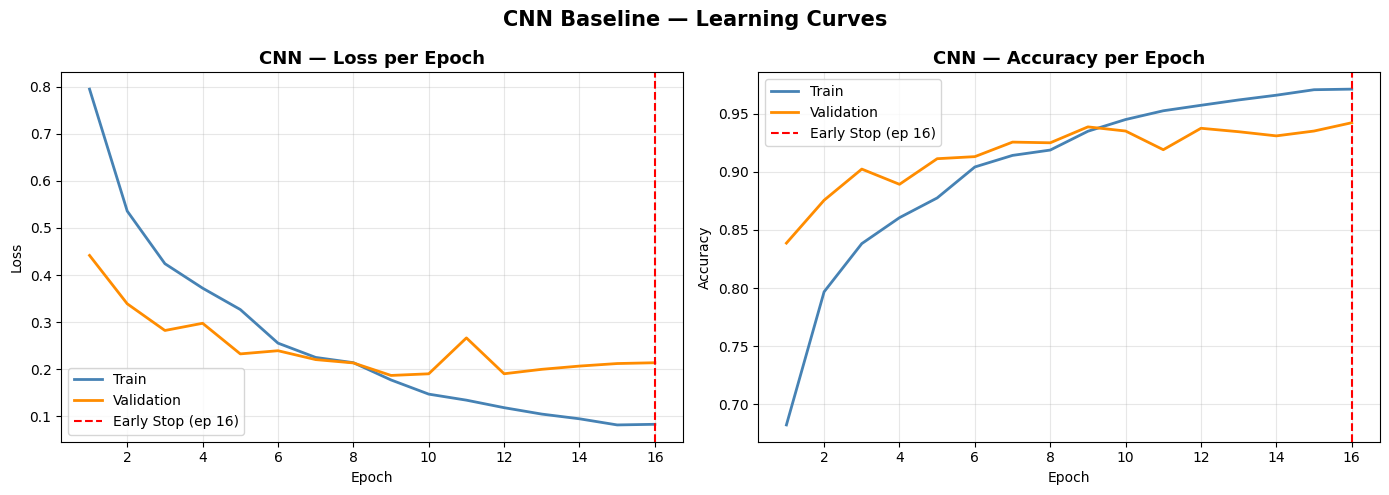

Saved: cnn_learning_curves.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ep = range(1, epochs_run + 1)

for ax, train_vals, val_vals, ylabel, title in zip(
    axes,
    [train_losses, train_accs],
    [val_losses,   val_accs],
    ['Loss', 'Accuracy'],
    ['Loss per Epoch', 'Accuracy per Epoch']
):
    ax.plot(ep, train_vals, label='Train',      color='steelblue',  linewidth=2)
    ax.plot(ep, val_vals,   label='Validation', color='darkorange', linewidth=2)
    if stopped_epoch:
        ax.axvline(x=stopped_epoch, color='red', linestyle='--',
                   linewidth=1.5, label=f'Early Stop (ep {stopped_epoch})')
    ax.set_title(f'CNN — {title}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('CNN Baseline — Learning Curves', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(CNN_OUT, "cnn_learning_curves.png"), dpi=120)
plt.show()
print("Saved: cnn_learning_curves.png")

### 9. Test Set Evaluation & Inference Speed

The test set is used **exactly once**  here  to produce the final unbiased performance number. It was never seen during training or validation.

**Why F1 (macro) alongside accuracy:**
With 4 classes, accuracy alone can be misleading if the model performs poorly on one class. Macro F1 averages the F1 score per class equally, giving a fairer view of performance across all tumour types — including the minority of predictions.

**Inference speed** (samples/second) is measured for comparison table.

CNN — Test Set Results
Accuracy (test)      : 0.8956  (89.56%)
F1 macro (test)      : 0.8938
Inference time       : 0.406s  for 1600 samples
Inference speed      : 3943.9 samples/sec

              precision    recall  f1-score   support

      glioma       0.92      0.75      0.83       400
  meningioma       0.82      0.88      0.85       400
     notumor       0.89      0.99      0.94       400
   pituitary       0.96      0.96      0.96       400

    accuracy                           0.90      1600
   macro avg       0.90      0.90      0.89      1600
weighted avg       0.90      0.90      0.89      1600



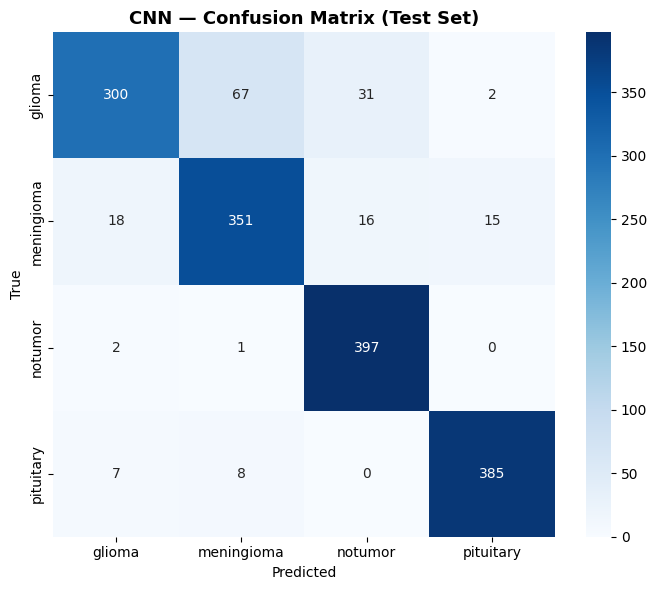

Saved: cnn_confusion_matrix.png


In [ ]:
model.eval()
all_preds, all_labels = [], []

infer_start = time.time()
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        outputs = model(X_batch.to(device))
        preds   = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y_batch.numpy())

infer_time  = time.time() - infer_start
n_test      = len(all_labels)
infer_speed = n_test / infer_time

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

test_acc = accuracy_score(all_labels, all_preds)
test_f1  = f1_score(all_labels, all_preds, average='macro')

print("=" * 50)
print("CNN — Test Set Results")
print("=" * 50)
print(f"Accuracy (test)      : {test_acc:.4f}  ({test_acc*100:.2f}%)")
print(f"F1 macro (test)      : {test_f1:.4f}")
print(f"Inference time       : {infer_time:.3f}s  for {n_test} samples")
print(f"Inference speed      : {infer_speed:.1f} samples/sec")
print()
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('CNN — Confusion Matrix (Test Set)', fontsize=13, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.savefig(os.path.join(CNN_OUT, "cnn_confusion_matrix.png"), dpi=120)
plt.show()
print("Saved: cnn_confusion_matrix.png")

### 10. Save Model & Results

All outputs are saved to `output/cnn_results/` for use by (CNN optimisation) and (final evaluation and comparison table).

| File | Used by |
|---|---|
| `cnn_baseline.pth` |CNN optimisation - loads baseline weights before optimisation |
| `cnn_train_loss.npy` / `cnn_val_loss.npy` | CNN optimisation & final evaluation and comparison - learning curve plots |
| `cnn_train_acc.npy` / `cnn_val_acc.npy` | CNN optimisation & final evaluation and comparison - accuracy tracking |
| `cnn_baseline_summary.json` | final evaluation and comparison - comparison table (timing, metrics, architecture) |

In [ ]:
# Loss and accuracy arrays
np.save(os.path.join(CNN_OUT, "cnn_train_loss.npy"), train_losses)
np.save(os.path.join(CNN_OUT, "cnn_val_loss.npy"),   val_losses)
np.save(os.path.join(CNN_OUT, "cnn_train_acc.npy"),  train_accs)
np.save(os.path.join(CNN_OUT, "cnn_val_acc.npy"),    val_accs)

# Model weights
torch.save(model.state_dict(), os.path.join(CNN_OUT, "cnn_baseline.pth"))

# Summary JSON for Person 6's comparison table
summary = {
    "model"                : "CNN_baseline",
    "image_size"           : [H, W, C],
    "num_classes"          : NUM_CLASSES,
    "class_names"          : CLASS_NAMES,
    "epochs_run"           : int(epochs_run),
    "early_stop_epoch"     : int(stopped_epoch) if stopped_epoch else None,
    "total_training_time_s": round(float(total_time), 2),
    "avg_epoch_time_s"     : round(float(avg_epoch_time), 2),
    "best_val_loss"        : round(float(val_losses.min()), 4),
    "best_val_acc"         : round(float(val_accs.max()), 4),
    "test_accuracy"        : round(float(test_acc), 4),
    "test_f1_macro"        : round(float(test_f1), 4),
    "inference_speed_sps"  : round(float(infer_speed), 1),
    "hyperparameters": {
        "batch_size"    : BATCH_SIZE,
        "learning_rate" : LEARNING_RATE,
        "optimizer"     : "Adam",
        "loss_function" : "CrossEntropyLoss",
        "max_epochs"    : NUM_EPOCHS,
    },
    "architecture": {
        "conv_blocks"    : 3,
        "filters"        : [32, 64, 128],
        "kernel_size"    : 3,
        "padding"        : 1,
        "pooling"        : "MaxPool2d(2)",
        "dropout_conv"   : 0.25,
        "fc_neurons"     : 512,
        "dropout_fc"     : 0.5,
        "activation"     : "ReLU",
        "batch_norm"     : True,
        "flatten_size"   : int(FLATTEN_SIZE),
    }
}

with open(os.path.join(CNN_OUT, "cnn_baseline_summary.json"), "w") as f:
    json.dump(summary, f, indent=4)

print("Saved to output/cnn_results/")
print("  cnn_train_loss.npy  cnn_val_loss.npy")
print("  cnn_train_acc.npy   cnn_val_acc.npy")
print("  cnn_baseline.pth")
print("  cnn_baseline_summary.json")
print("  cnn_learning_curves.png")
print("  cnn_confusion_matrix.png")
print()
print("Person 5 → load weights : output/cnn_results/cnn_baseline.pth")
print("Person 6 → load arrays  : output/cnn_results/cnn_*.npy")
print("Person 6 → load summary : output/cnn_results/cnn_baseline_summary.json")

Saved to output/cnn_results/
  cnn_train_loss.npy  cnn_val_loss.npy
  cnn_train_acc.npy   cnn_val_acc.npy
  cnn_baseline.pth
  cnn_baseline_summary.json
  cnn_learning_curves.png
  cnn_confusion_matrix.png

Person 5 → load weights : output/cnn_results/cnn_baseline.pth
Person 6 → load arrays  : output/cnn_results/cnn_*.npy
Person 6 → load summary : output/cnn_results/cnn_baseline_summary.json


### CNN optimization

## CNN Optimization — Setup & Initialization

This cell initializes the optimization environment before running any trials.

steps:
- Imports `json` and `numpy` to load the baseline results and manage arrays.
- Creates the output directory `output/cnn_opt_results/` where all trial models, metrics, and summaries will be saved.
- Loads the baseline CNN summary JSON (produced in the previous section) to extract the baseline validation accuracy and test accuracy — these become the fixed reference point for every trial comparison.
- Initializes `all_trials`, an empty list that will accumulate the result dictionary of every trial. This list is never reset between trials, so we always have the full experiment history to compare at the end.

**  Why we do this:

Every optimization trial must be measured against a consistent baseline. Locking the baseline numbers here prevents any accidental overwriting or ambiguity later. The `all_trials` list is the single source of truth for the summary table in Trial 6.

In [ ]:

# PERSON 5 — CNN OPTIMIZATION

import json
import numpy as np

CNN_OPT_OUT = "output/cnn_opt_results"
os.makedirs(CNN_OPT_OUT, exist_ok=True)

# load baseline results from Person 4 for comparison
baseline_summary  = json.load(open("output/cnn_results/cnn_baseline_summary.json"))
BASELINE_VAL_ACC  = baseline_summary["best_val_acc"]
BASELINE_TEST_ACC = baseline_summary["test_accuracy"]

print(f"Baseline val acc  : {BASELINE_VAL_ACC:.4f}")
print(f"Baseline test acc : {BASELINE_TEST_ACC:.4f}")

# this list collects every trial result — never delete from it
all_trials = []

Baseline val acc  : 0.9423
Baseline test acc : 0.8956


## `reset_trial()` — Trial Factory Function

This function rebuilds the entire model from scratch before each trial, ensuring every experiment starts from the same clean state.

**Parameters it accepts:**
- `filter_list` — number of convolutional filters per block, e.g. `[32, 64, 128]`
- `kernel_size` — size of each convolutional kernel (3×3 or 5×5)
- `pooling` — spatial downsampling strategy: `"max"` or `"avg"`
- `fc_neurons` — number of neurons in the fully connected hidden layer

**What it does to the images (internally):**
Before building the real model, it runs a **dummy forward pass** — it constructs a temporary conv-only network with the given parameters and passes a zero-filled tensor of shape `(1, C, H, W)` through it. It reads the output shape to automatically compute `flatten_size` — the exact number of values that exit the conv blocks and flow into the first fully connected layer. This is critical because `flatten_size` changes whenever filters, blocks, or pooling change.

**Why we reset everything each trial:**
Reusing weights from a previous trial would bias the results — the model would start from a non-neutral point, making it impossible to fairly compare architectures. Resetting the model, optimizer (Adam with fresh moment estimates), and early stopping counter ensures each trial is a fully independent experiment where only the architectural parameter being tested differs.

**Why `patience=7` and `min_delta=0.001`:**
These match the baseline CNN exactly. Keeping them fixed means early stopping behaviour is not an uncontrolled variable across trials.

In [ ]:
def reset_trial(filter_list=[32, 64, 128], kernel_size=3,
                pooling="max", fc_neurons=512):

    # ── Recompute flatten size for THIS trial's architecture ──
    _dummy_conv = nn.Sequential(*[
        layer
        for i, filters in enumerate(filter_list)
        for layer in [
            nn.Conv2d(C if i == 0 else filter_list[i-1],
                      filters, kernel_size=kernel_size, padding=kernel_size // 2),
            nn.BatchNorm2d(filters),
            nn.ReLU(),
            nn.MaxPool2d(2) if pooling == "max" else nn.AvgPool2d(2),
            nn.Dropout2d(0.25),
        ]
    ])

    with torch.no_grad():
        _x = torch.zeros(1, C, H, W)
        _x = _dummy_conv(_x)
        flatten_size = _x.view(1, -1).shape[1]

    del _dummy_conv, _x
    print(f"  → flatten_size for {filter_list}: {flatten_size}")

    # ── Instantiate model with the correct flatten size ──
    model = CNN(C, NUM_CLASSES, flatten_size,
                filter_list=filter_list,
                kernel_size=kernel_size,
                pooling=pooling,
                fc_neurons=fc_neurons).to(device)

    optimizer      = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    early_stopping = EarlyStoppingCNN(patience=7, min_delta=0.001)
    criterion      = nn.CrossEntropyLoss()

    return model, optimizer, criterion, early_stopping

## Trial 1 — Fewer Convolutional Blocks: `[32, 64]`

**What changes from baseline:** The network is reduced from 3 conv blocks to 2. The third block (128 filters) is removed entirely.

**What this does to the images step by step:**
1. **Block 1 — 32 filters, 3×3 kernel:** Scans the preprocessed 128×128 grayscale MRI with 32 different filters. Each filter learns to detect a distinct low-level pattern — edges, intensity boundaries, brightness gradients. Output: 32 feature maps, still 128×128. After MaxPool: 64×64.
2. **Block 2 — 64 filters:** Receives the 64×64 pooled feature maps and applies 64 filters to detect mid-level combinations — curves, blob shapes, texture regions formed by edges found in Block 1. After MaxPool: 32×32.
3. **No Block 3:** High-level feature extraction is removed. The model never learns to detect complex spatial structures like tumour boundaries, mass effects, or heterogeneous tissue patterns that only emerge from stacking multiple abstraction levels.
4. The feature maps are then flattened and passed to the fully connected head.

**Hypothesis:** Removing one layer reduces the model's parameter count and complexity. If the baseline was overfitting (memorising training examples), a shallower network might generalise better.

**What to watch for:** If validation accuracy drops noticeably, the third block was carrying genuinely useful representational capacity and is not just adding noise. If it holds close to baseline, the architecture was over-parameterised for this dataset size.

In [ ]:

model, optimizer, criterion, early_stopping = reset_trial(
    filter_list = [32, 64]
)

print("=" * 72)
print("TRIAL 1 — 2 Conv Blocks [32, 64]")
print("=" * 72)

(train_losses, val_losses,
 train_accs,   val_accs,
 epoch_times,  stopped_epoch) = train_model(
    model, train_loader, val_loader,
    optimizer, criterion, NUM_EPOCHS, early_stopping
)

print(f"  best val acc  : {val_accs.max():.4f}  (epoch {val_accs.argmax()+1})")
print(f"  best val loss : {val_losses.min():.4f}")
print(f"  early stop    : {stopped_epoch if stopped_epoch else 'N/A'}")

all_trials.append({
    "trial"        : "Trial 1 — 2 blocks [32,64]",
    "config"       : {"filter_list": [32,64], "kernel_size": 3, "pooling": "max"},
    "best_val_acc" : float(val_accs.max()),
    "best_val_loss": float(val_losses.min()),
    "stopped_epoch": stopped_epoch,
    "epochs_run"   : len(train_losses),
    "train_losses" : train_losses.tolist(),
    "val_losses"   : val_losses.tolist(),
    "train_accs"   : train_accs.tolist(),
    "val_accs"     : val_accs.tolist(),
})


  → flatten_size for [32, 64]: 65536
TRIAL 1 — 2 Conv Blocks [32, 64]
Epoch [01/50] | Train Loss: 0.7767  Acc: 0.6941 | Val Loss: 0.4078  Acc: 0.8524 | 7.8s
Epoch [02/50] | Train Loss: 0.5312  Acc: 0.7963 | Val Loss: 0.3385  Acc: 0.8726 | 7.8s
Epoch [03/50] | Train Loss: 0.4303  Acc: 0.8402 | Val Loss: 0.2926  Acc: 0.8946 | 7.8s
Epoch [04/50] | Train Loss: 0.3577  Acc: 0.8630 | Val Loss: 0.2707  Acc: 0.8940 | 7.7s
Epoch [05/50] | Train Loss: 0.2894  Acc: 0.8913 | Val Loss: 0.2558  Acc: 0.9042 | 7.8s
Epoch [06/50] | Train Loss: 0.2370  Acc: 0.9125 | Val Loss: 0.2325  Acc: 0.9131 | 7.7s
Epoch [07/50] | Train Loss: 0.1966  Acc: 0.9259 | Val Loss: 0.2537  Acc: 0.9101 | 7.8s
   EarlyStopping: 1/7 epochs without improvement
Epoch [08/50] | Train Loss: 0.1577  Acc: 0.9416 | Val Loss: 0.2297  Acc: 0.9274 | 7.8s
Epoch [09/50] | Train Loss: 0.1332  Acc: 0.9514 | Val Loss: 0.2290  Acc: 0.9185 | 7.7s
   EarlyStopping: 1/7 epochs without improvement
Epoch [10/50] | Train Loss: 0.1173  Acc: 0.9596 |

## Trial 2 — More Convolutional Blocks: `[32, 64, 128, 256]`

**What changes from baseline:** A fourth convolutional block with 256 filters is added, making the network one layer deeper than the baseline.

**What this does to the images step by step:**
1. **Blocks 1–3** behave identically to the baseline: low-level edges → mid-level textures → high-level structures.
2. **Block 4 — 256 filters:** Receives 16×16 feature maps from Block 3's pooling layer and applies 256 filters to detect highly abstract, class-discriminative patterns — spatial arrangements of tumour tissue, shape asymmetries, complex structural descriptors that distinguish one tumour type from another at a high level. After MaxPool: 8×8.
3. The 8×8×256 feature maps are flattened (16,384 values) and passed to the FC head. This is the same total values as the baseline (16×16×128 = 32,768? no — actually 8×8×256 = 16,384 vs 16×16×128 = 32,768), so the FC head receives a more compressed but richer representation.

**Hypothesis:** Deeper networks can capture finer MRI features that three blocks miss — particularly subtle structural differences between glioma, meningioma, and pituitary tumours that require multiple levels of abstraction to distinguish.

**Trade-off to watch:** More blocks mean more parameters and longer training. Dropout2d(0.25) and BatchNorm are present in every block as regularizers, but if the dataset is too small relative to model capacity, the fourth block may overfit rather than generalise.

In [ ]:


model, optimizer, criterion, early_stopping = reset_trial(
    filter_list = [32, 64, 128, 256]   # ← only change
)

print("=" * 72)
print("TRIAL 2 — 4 Conv Blocks [32, 64, 128, 256]")
print("=" * 72)

(train_losses, val_losses,
 train_accs,   val_accs,
 epoch_times,  stopped_epoch) = train_model(
    model, train_loader, val_loader,
    optimizer, criterion, NUM_EPOCHS, early_stopping
)

print(f"  best val acc  : {val_accs.max():.4f}  (epoch {val_accs.argmax()+1})")
print(f"  best val loss : {val_losses.min():.4f}")
print(f"  early stop    : {stopped_epoch if stopped_epoch else 'N/A'}")

all_trials.append({
    "trial"        : "Trial 2 — 4 blocks [32,64,128,256]",
    "config"       : {"filter_list": [32,64,128,256], "kernel_size": 3, "pooling": "max"},
    "best_val_acc" : float(val_accs.max()),
    "best_val_loss": float(val_losses.min()),
    "stopped_epoch": stopped_epoch,
    "epochs_run"   : len(train_losses),
    "train_losses" : train_losses.tolist(),
    "val_losses"   : val_losses.tolist(),
    "train_accs"   : train_accs.tolist(),
    "val_accs"     : val_accs.tolist(),
})



  → flatten_size for [32, 64, 128, 256]: 16384
TRIAL 2 — 4 Conv Blocks [32, 64, 128, 256]
Epoch [01/50] | Train Loss: 0.8380  Acc: 0.6593 | Val Loss: 0.4316  Acc: 0.8500 | 7.2s
Epoch [02/50] | Train Loss: 0.5507  Acc: 0.7892 | Val Loss: 0.3232  Acc: 0.8804 | 7.3s
Epoch [03/50] | Train Loss: 0.4470  Acc: 0.8305 | Val Loss: 0.2861  Acc: 0.8935 | 7.3s
Epoch [04/50] | Train Loss: 0.3692  Acc: 0.8589 | Val Loss: 0.2401  Acc: 0.9167 | 7.3s
Epoch [05/50] | Train Loss: 0.3126  Acc: 0.8825 | Val Loss: 0.2292  Acc: 0.9196 | 7.3s
Epoch [06/50] | Train Loss: 0.2820  Acc: 0.8952 | Val Loss: 0.2070  Acc: 0.9268 | 7.3s
Epoch [07/50] | Train Loss: 0.2265  Acc: 0.9180 | Val Loss: 0.1980  Acc: 0.9345 | 7.3s
Epoch [08/50] | Train Loss: 0.2047  Acc: 0.9210 | Val Loss: 0.2102  Acc: 0.9280 | 7.3s
   EarlyStopping: 1/7 epochs without improvement
Epoch [09/50] | Train Loss: 0.1830  Acc: 0.9310 | Val Loss: 0.2357  Acc: 0.9238 | 7.3s
   EarlyStopping: 2/7 epochs without improvement
Epoch [10/50] | Train Loss: 0

In [ ]:

model, optimizer, criterion, early_stopping = reset_trial(
    filter_list = [64, 128, 256]   # ← only change
)

print("=" * 72)
print("TRIAL 3 — Wider Filters [64, 128, 256]")
print("=" * 72)

(train_losses, val_losses,
 train_accs,   val_accs,
 epoch_times,  stopped_epoch) = train_model(
    model, train_loader, val_loader,
    optimizer, criterion, NUM_EPOCHS, early_stopping
)

print(f"  best val acc  : {val_accs.max():.4f}  (epoch {val_accs.argmax()+1})")
print(f"  best val loss : {val_losses.min():.4f}")
print(f"  early stop    : {stopped_epoch if stopped_epoch else 'N/A'}")

all_trials.append({
    "trial"        : "Trial 3 — wider filters [64,128,256]",
    "config"       : {"filter_list": [64,128,256], "kernel_size": 3, "pooling": "max"},
    "best_val_acc" : float(val_accs.max()),
    "best_val_loss": float(val_losses.min()),
    "stopped_epoch": stopped_epoch,
    "epochs_run"   : len(train_losses),
    "train_losses" : train_losses.tolist(),
    "val_losses"   : val_losses.tolist(),
    "train_accs"   : train_accs.tolist(),
    "val_accs"     : val_accs.tolist(),
})


  → flatten_size for [64, 128, 256]: 65536
TRIAL 3 — Wider Filters [64, 128, 256]
Epoch [01/50] | Train Loss: 0.7509  Acc: 0.7037 | Val Loss: 0.4110  Acc: 0.8440 | 14.7s
Epoch [02/50] | Train Loss: 0.4880  Acc: 0.8130 | Val Loss: 0.3031  Acc: 0.8917 | 14.7s
Epoch [03/50] | Train Loss: 0.3842  Acc: 0.8543 | Val Loss: 0.2598  Acc: 0.9030 | 14.7s
Epoch [04/50] | Train Loss: 0.3234  Acc: 0.8835 | Val Loss: 0.2254  Acc: 0.9179 | 14.7s
Epoch [05/50] | Train Loss: 0.2737  Acc: 0.8938 | Val Loss: 0.3114  Acc: 0.8869 | 14.8s
   EarlyStopping: 1/7 epochs without improvement
Epoch [06/50] | Train Loss: 0.2278  Acc: 0.9129 | Val Loss: 0.1925  Acc: 0.9292 | 14.8s
Epoch [07/50] | Train Loss: 0.1955  Acc: 0.9302 | Val Loss: 0.1962  Acc: 0.9280 | 14.8s
   EarlyStopping: 1/7 epochs without improvement
Epoch [08/50] | Train Loss: 0.1614  Acc: 0.9407 | Val Loss: 0.1706  Acc: 0.9423 | 14.8s
Epoch [09/50] | Train Loss: 0.1537  Acc: 0.9432 | Val Loss: 0.2545  Acc: 0.9161 | 14.8s
   EarlyStopping: 1/7 epochs

## Trial 4 — Larger Convolutional Kernel: `5×5`

**What changes from baseline:** The convolutional kernel is changed from 3×3 to 5×5. Filter counts and block structure remain identical to the baseline: `[32, 64, 128]`, 3 blocks.

**What this does to the images step by step:**
1. **Larger receptive field per operation:** A 5×5 kernel looks at a 5-pixel-wide neighbourhood at each position, compared to 3 pixels for the 3×3 baseline. This means each filter response is influenced by a broader region of the image at every single convolution operation.
2. **Same spatial dimensions are preserved:** `padding = kernel_size // 2 = 2` is used, which pads the image by 2 pixels on each side before convolution. This ensures the output feature map is exactly the same size as the input — identical to how `padding=1` works for the 3×3 kernel. MaxPool still halves dimensions each block: 128→64→32→16. Flatten size is unchanged at 32,768.
3. **Compounded receptive field growth:** After three 5×5 conv layers (plus MaxPooling), each neuron in the final feature map is effectively sensitive to a larger region of the original MRI image compared to the 3×3 baseline. The model "sees more context" at each point.

**Hypothesis for MRI:** Brain tumours often span large contiguous regions of the scan — oedema halos, mass displacement, irregular boundaries. A 5×5 kernel can capture broader spatial context in each convolution, which may help detect tumour boundaries and regional asymmetry that a 3×3 kernel would need multiple stacked layers to aggregate.

**Trade-off to watch:** 5×5 kernels have 25 weights per filter vs 9 for 3×3 — 2.78× more parameters per layer. Training is slower and overfitting risk is higher. Modern architectures (VGG, ResNet) typically prefer stacked 3×3 layers to achieve the same receptive field more efficiently, but this trial tests whether the direct larger kernel is beneficial here.

In [ ]:


model, optimizer, criterion, early_stopping = reset_trial(
    kernel_size = 5   # ← only change
)

print("=" * 72)
print("TRIAL 4 — Kernel 5x5")
print("=" * 72)

(train_losses, val_losses,
 train_accs,   val_accs,
 epoch_times,  stopped_epoch) = train_model(
    model, train_loader, val_loader,
    optimizer, criterion, NUM_EPOCHS, early_stopping
)

print(f"  best val acc  : {val_accs.max():.4f}  (epoch {val_accs.argmax()+1})")
print(f"  best val loss : {val_losses.min():.4f}")
print(f"  early stop    : {stopped_epoch if stopped_epoch else 'N/A'}")

all_trials.append({
    "trial"        : "Trial 4 — kernel 5x5",
    "config"       : {"filter_list": [32,64,128], "kernel_size": 5, "pooling": "max"},
    "best_val_acc" : float(val_accs.max()),
    "best_val_loss": float(val_losses.min()),
    "stopped_epoch": stopped_epoch,
    "epochs_run"   : len(train_losses),
    "train_losses" : train_losses.tolist(),
    "val_losses"   : val_losses.tolist(),
    "train_accs"   : train_accs.tolist(),
    "val_accs"     : val_accs.tolist(),
})



  → flatten_size for [32, 64, 128]: 32768
TRIAL 4 — Kernel 5x5
Epoch [01/50] | Train Loss: 0.8242  Acc: 0.6670 | Val Loss: 0.4346  Acc: 0.8435 | 11.6s
Epoch [02/50] | Train Loss: 0.5559  Acc: 0.7856 | Val Loss: 0.3354  Acc: 0.8738 | 11.5s
Epoch [03/50] | Train Loss: 0.4638  Acc: 0.8235 | Val Loss: 0.3327  Acc: 0.8720 | 11.5s
Epoch [04/50] | Train Loss: 0.3768  Acc: 0.8579 | Val Loss: 0.2752  Acc: 0.8982 | 11.5s
Epoch [05/50] | Train Loss: 0.3094  Acc: 0.8885 | Val Loss: 0.2869  Acc: 0.9000 | 11.4s
   EarlyStopping: 1/7 epochs without improvement
Epoch [06/50] | Train Loss: 0.2911  Acc: 0.8894 | Val Loss: 0.2248  Acc: 0.9173 | 11.4s
Epoch [07/50] | Train Loss: 0.2457  Acc: 0.9131 | Val Loss: 0.2006  Acc: 0.9226 | 11.4s
Epoch [08/50] | Train Loss: 0.1989  Acc: 0.9249 | Val Loss: 0.2290  Acc: 0.9185 | 11.5s
   EarlyStopping: 1/7 epochs without improvement
Epoch [09/50] | Train Loss: 0.1792  Acc: 0.9349 | Val Loss: 0.1891  Acc: 0.9345 | 11.5s
Epoch [10/50] | Train Loss: 0.1623  Acc: 0.9395

## Trial 5 — Average Pooling Instead of Max Pooling

**What changes from baseline:** Every `MaxPool2d(2)` layer is replaced with `AvgPool2d(2)`. Architecture, filter counts, and kernel size are identical to the baseline: `[32, 64, 128]`, 3 blocks, 3×3 kernels.

**What each pooling type does to the feature maps:**
- **MaxPool2d(2):** Divides the feature map into non-overlapping 2×2 windows and keeps only the **maximum** value from each window. This aggressively retains the strongest activation — whichever pixel responded most intensely to the filter — while discarding the other three values entirely. It asks: "does this feature exist anywhere in this region?"
- **AvgPool2d(2):** Takes the **mean** of all four values in each 2×2 window. This smooths the feature map, retaining information about the average response across the region. Stronger activations are diluted, but diffuse signals spread across the region are preserved.
- Both reduce spatial dimensions by the same factor — ÷2 per pool, ÷8 overall: 128→64→32→16. Flatten size is unchanged.

**Hypothesis for MRI:** MRI brain scans encode diagnostic information across large, smooth, distributed regions — tumour mass, surrounding oedema, ventricle displacement — not just at sharp local edges. Average pooling may preserve more of this diffuse spatial signal. Max pooling discards everything except the peak activation in each region, which is ideal for detecting whether a sharp feature is present, but may lose the broader regional context that differentiates tumour types in MRI.

**What to watch for:** If average pooling outperforms max pooling here, it suggests the CNN benefits more from smooth regional information than from peak feature detection. If max pooling is still better, it confirms that the most discriminative MRI features are localized and well captured by the maximum response.

In [ ]:

model, optimizer, criterion, early_stopping = reset_trial(
    pooling = "avg"   # ← only change
)

print("=" * 72)
print("TRIAL 5 — Average Pooling")
print("=" * 72)

(train_losses, val_losses,
 train_accs,   val_accs,
 epoch_times,  stopped_epoch) = train_model(
    model, train_loader, val_loader,
    optimizer, criterion, NUM_EPOCHS, early_stopping
)

print(f"  best val acc  : {val_accs.max():.4f}  (epoch {val_accs.argmax()+1})")
print(f"  best val loss : {val_losses.min():.4f}")
print(f"  early stop    : {stopped_epoch if stopped_epoch else 'N/A'}")

all_trials.append({
    "trial"        : "Trial 5 — avg pooling",
    "config"       : {"filter_list": [32,64,128], "kernel_size": 3, "pooling": "avg"},
    "best_val_acc" : float(val_accs.max()),
    "best_val_loss": float(val_losses.min()),
    "stopped_epoch": stopped_epoch,
    "epochs_run"   : len(train_losses),
    "train_losses" : train_losses.tolist(),
    "val_losses"   : val_losses.tolist(),
    "train_accs"   : train_accs.tolist(),
    "val_accs"     : val_accs.tolist(),
})


  → flatten_size for [32, 64, 128]: 32768
TRIAL 5 — Average Pooling
Epoch [01/50] | Train Loss: 0.7756  Acc: 0.6926 | Val Loss: 0.4006  Acc: 0.8542 | 7.5s
Epoch [02/50] | Train Loss: 0.5297  Acc: 0.7964 | Val Loss: 0.3394  Acc: 0.8744 | 7.4s
Epoch [03/50] | Train Loss: 0.4355  Acc: 0.8337 | Val Loss: 0.3195  Acc: 0.8851 | 7.4s
Epoch [04/50] | Train Loss: 0.3824  Acc: 0.8561 | Val Loss: 0.2505  Acc: 0.9060 | 7.4s
Epoch [05/50] | Train Loss: 0.3287  Acc: 0.8765 | Val Loss: 0.2432  Acc: 0.9095 | 7.4s
Epoch [06/50] | Train Loss: 0.2700  Acc: 0.8977 | Val Loss: 0.2334  Acc: 0.9101 | 7.4s
Epoch [07/50] | Train Loss: 0.2424  Acc: 0.9082 | Val Loss: 0.2317  Acc: 0.9155 | 7.4s
Epoch [08/50] | Train Loss: 0.1980  Acc: 0.9228 | Val Loss: 0.2126  Acc: 0.9304 | 7.4s
Epoch [09/50] | Train Loss: 0.1825  Acc: 0.9309 | Val Loss: 0.2098  Acc: 0.9345 | 7.4s
Epoch [10/50] | Train Loss: 0.1625  Acc: 0.9397 | Val Loss: 0.2111  Acc: 0.9333 | 7.4s
   EarlyStopping: 1/7 epochs without improvement
Epoch [11/50]

## Trial 6 — Best Combined Configuration (Auto-Selected)

**What changes:** This trial combines the best-performing choice from each of Trials 1–5 into a single architecture. The winning `filter_list`, `kernel_size`, and `pooling` type are selected automatically by comparing each trial's best validation accuracy against the baseline — no manual decision is made.

**Selection logic:**
- `filter_list` → whichever of Trials 1, 2, or 3 produced the highest validation accuracy (fewer blocks, more blocks, or wider filters)
- `kernel_size` → `5` if Trial 4 exceeded baseline validation accuracy, otherwise `3`
- `pooling` → `"avg"` if Trial 5 exceeded baseline validation accuracy, otherwise `"max"`

**What this does to the images:**
The combined configuration applies the best-discovered settings simultaneously at every stage of the forward pass — from how many filters scan the image at each block, to how wide each filter's view is, to how the resulting feature maps are downsampled. Each individual choice was already validated in isolation; this trial tests whether the improvements are **additive** (they compound together) or whether they suffer **diminishing returns** (the gains overlap or conflict).

**Why auto-select instead of hardcoding:**
Hardcoding the "best" config based on expected results would be confirmation bias. The auto-selection logic reads the actual recorded `best_val_acc` from `all_trials` and picks winners objectively. This means the notebook always selects the genuinely best config regardless of which trials performed better or worse than anticipated.

**Final evaluation:**
After Trial 6, the overall best trial across all six is identified. If Trial 6 is not the top performer, the actual best config is re-trained from scratch and its weights are used for the test set evaluation and the final saved outputs.

In [ ]:


# Auto-pick winners from actual trial results
trials_1_3 = [t for t in all_trials if any(f"Trial {i}" in t["trial"] for i in [1, 2, 3])]
BEST_FILTER_LIST = max(trials_1_3, key=lambda x: x["best_val_acc"])["config"]["filter_list"]

trial_4 = next(t for t in all_trials if "Trial 4" in t["trial"])
BEST_KERNEL_SIZE = 5 if trial_4["best_val_acc"] > BASELINE_VAL_ACC else 3

trial_5 = next(t for t in all_trials if "Trial 5" in t["trial"])
BEST_POOLING = "avg" if trial_5["best_val_acc"] > BASELINE_VAL_ACC else "max"

print(f"  Auto-selected config:")
print(f"  filter_list : {BEST_FILTER_LIST}")
print(f"  kernel_size : {BEST_KERNEL_SIZE}")
print(f"  pooling     : {BEST_POOLING}")

model, optimizer, criterion, early_stopping = reset_trial(
    filter_list = BEST_FILTER_LIST,
    kernel_size = BEST_KERNEL_SIZE,
    pooling     = BEST_POOLING
)

print("=" * 72)
print(f"TRIAL 6 — Best Combined Config")
print(f"  filter_list : {BEST_FILTER_LIST}")
print(f"  kernel_size : {BEST_KERNEL_SIZE}")
print(f"  pooling     : {BEST_POOLING}")
print("=" * 72)

(train_losses, val_losses,
 train_accs,   val_accs,
 epoch_times,  stopped_epoch) = train_model(
    model, train_loader, val_loader,
    optimizer, criterion, NUM_EPOCHS, early_stopping
)

print(f"  best val acc  : {val_accs.max():.4f}  (epoch {val_accs.argmax()+1})")
print(f"  best val loss : {val_losses.min():.4f}")
print(f"  early stop    : {stopped_epoch if stopped_epoch else 'N/A'}")

all_trials.append({
    "trial"        : "Trial 6 — best combined",
    "config"       : {"filter_list": BEST_FILTER_LIST,
                      "kernel_size": BEST_KERNEL_SIZE,
                      "pooling"    : BEST_POOLING},
    "best_val_acc" : float(val_accs.max()),
    "best_val_loss": float(val_losses.min()),
    "stopped_epoch": stopped_epoch,
    "epochs_run"   : len(train_losses),
    "train_losses" : train_losses.tolist(),
    "val_losses"   : val_losses.tolist(),
    "train_accs"   : train_accs.tolist(),
    "val_accs"     : val_accs.tolist(),
})

# Identify overall best trial (including Trial 6)
best = max(all_trials, key=lambda x: x["best_val_acc"])
best_cnn_config = best["config"]
print(f"\nBEST TRIAL : {best['trial']}")
print(f"  Val acc  : {best['best_val_acc']:.4f}")
print(f"  Config   : {best['config']}")

#  If Trial 6 is NOT the best, re-train on actual best config
if best["trial"] != "Trial 6 — best combined":
    print(f"\n  Trial 6 is not the best — re-training on: {best['trial']}")
    model, optimizer, criterion, early_stopping = reset_trial(
        filter_list = best["config"]["filter_list"],
        kernel_size = best["config"]["kernel_size"],
        pooling     = best["config"]["pooling"]
    )
    (train_losses, val_losses,
     train_accs,   val_accs,
     epoch_times,  stopped_epoch) = train_model(
        model, train_loader, val_loader,
        optimizer, criterion, NUM_EPOCHS, early_stopping
    )
    print(f"  Re-trained val acc : {val_accs.max():.4f}")
    best["train_losses"]  = train_losses.tolist()
    best["val_losses"]    = val_losses.tolist()
    best["train_accs"]    = train_accs.tolist()
    best["val_accs"]      = val_accs.tolist()
    best["epochs_run"]    = len(train_losses)
    best["stopped_epoch"] = stopped_epoch

#  Test set evaluation on the final best model
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        preds = model(X_batch.to(device)).argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y_batch.numpy())

opt_test_acc = accuracy_score(all_labels, all_preds)
opt_test_f1  = f1_score(all_labels, all_preds, average="macro")

print()
print("=" * 72)
print("Optimized CNN — Test Set Results")
print("=" * 72)
print(f"  Test accuracy   : {opt_test_acc:.4f}  ({opt_test_acc*100:.2f}%)")
print(f"  Test F1 macro   : {opt_test_f1:.4f}")
print(f"  vs baseline acc : {BASELINE_TEST_ACC:.4f}  ({opt_test_acc - BASELINE_TEST_ACC:+.4f})")


  Auto-selected config:
  filter_list : [32, 64, 128, 256]
  kernel_size : 5
  pooling     : max
  → flatten_size for [32, 64, 128, 256]: 16384
TRIAL 6 — Best Combined Config
  filter_list : [32, 64, 128, 256]
  kernel_size : 5
  pooling     : max
Epoch [01/50] | Train Loss: 0.9653  Acc: 0.6101 | Val Loss: 0.5561  Acc: 0.7952 | 14.4s
Epoch [02/50] | Train Loss: 0.6222  Acc: 0.7578 | Val Loss: 0.4014  Acc: 0.8512 | 14.4s
Epoch [03/50] | Train Loss: 0.4928  Acc: 0.8096 | Val Loss: 0.3561  Acc: 0.8512 | 14.3s
Epoch [04/50] | Train Loss: 0.4099  Acc: 0.8411 | Val Loss: 0.2498  Acc: 0.9095 | 14.3s
Epoch [05/50] | Train Loss: 0.3466  Acc: 0.8695 | Val Loss: 0.2069  Acc: 0.9280 | 14.3s
Epoch [06/50] | Train Loss: 0.2879  Acc: 0.8936 | Val Loss: 0.2058  Acc: 0.9280 | 14.3s
Epoch [07/50] | Train Loss: 0.2404  Acc: 0.9092 | Val Loss: 0.1852  Acc: 0.9363 | 14.3s
Epoch [08/50] | Train Loss: 0.2136  Acc: 0.9217 | Val Loss: 0.1837  Acc: 0.9375 | 14.4s
Epoch [09/50] | Train Loss: 0.1781  Acc: 0.9364 


## Optimization Summary Table

This cell prints a side-by-side comparison of all six trials against the baseline.

**What it shows:**
- Trial name and configuration tested
- Best validation accuracy achieved across all epochs
- Best validation loss achieved
- Number of epochs run (marked with `*` if early stopping triggered before the maximum)

**How to read it:**
The baseline row shows the reference point. Every trial row shows whether its architectural change moved validation accuracy up or down relative to that reference. The trial with the highest `Val Acc` in the table is identified as the best configuration and is carried forward to test set evaluation and final saving.

**Why validation accuracy and not test accuracy:**
The test set is used exactly once at the very end, on the final best model only. Using test accuracy to compare trials would constitute data leakage — the test set would be influencing architectural decisions, making the final reported test number an optimistic overestimate of real-world performance. Validation accuracy is the correct metric for all model selection decisions during optimization.

In [ ]:

print(f"\n{'='*72}")
print(f"{'TRIAL':<38} {'Val Acc':>9} {'Val Loss':>10} {'Epochs':>8}")
print(f"{'-'*72}")
print(f"{'Baseline (Person 4)':<38} {BASELINE_VAL_ACC:>9.4f}")

for t in all_trials:
    ep = str(t["epochs_run"]) + ("*" if t["stopped_epoch"] else "")
    print(f"{t['trial']:<38} {t['best_val_acc']:>9.4f} {t['best_val_loss']:>10.4f} {ep:>8}")

print(f"{'='*72}")
print("* = early stopping triggered")

# identify best trial
best = max(all_trials, key=lambda x: x["best_val_acc"])
print(f"\nBEST TRIAL : {best['trial']}")
print(f"  Val acc  : {best['best_val_acc']:.4f}")
print(f"  Config   : {best['config']}")


TRIAL                                    Val Acc   Val Loss   Epochs
------------------------------------------------------------------------
Baseline (Person 4)                       0.9423
Trial 1 — 2 blocks [32,64]                0.9315     0.2269      19*
Trial 2 — 4 blocks [32,64,128,256]        0.9476     0.1687      18*
Trial 3 — wider filters [64,128,256]      0.9452     0.1706      15*
Trial 4 — kernel 5x5                      0.9482     0.1661      18*
Trial 5 — avg pooling                     0.9417     0.1880      21*
Trial 6 — best combined                   0.9583     0.1472      28*
* = early stopping triggered

BEST TRIAL : Trial 6 — best combined
  Val acc  : 0.9583
  Config   : {'filter_list': [32, 64, 128, 256], 'kernel_size': 5, 'pooling': 'max'}


## Learning Curves — Best Optimization Trial

This cell plots training loss and validation loss per epoch for the best trial identified in the summary table above.

**What the two subplots show:**
- **Left — Loss per Epoch:** How quickly the model's prediction error decreases on training data (blue) and validation data (orange) across epochs. A good model shows both curves descending together and converging.
- **Right — Accuracy per Epoch:** The fraction of correctly classified images per epoch on train and validation sets. Should rise together and plateau close to each other.

**The red dashed vertical line** marks the epoch where early stopping triggered — the point where validation loss had not improved for 7 consecutive epochs and training was halted. The model weights restored are from the epoch just before the plateau began.

**Signs of overfitting to look for:**
- Train loss continues falling while val loss flattens or rises
- A growing gap between train accuracy and val accuracy
- Early stopping triggering while train loss is still visibly decreasing

**Why plot the best trial only:**
All six trials' curves were implicitly tracked during training (through `train_losses` and `val_losses` lists). Plotting only the best trial here keeps the output clean and focused on the configuration that will be saved and evaluated on the test set.

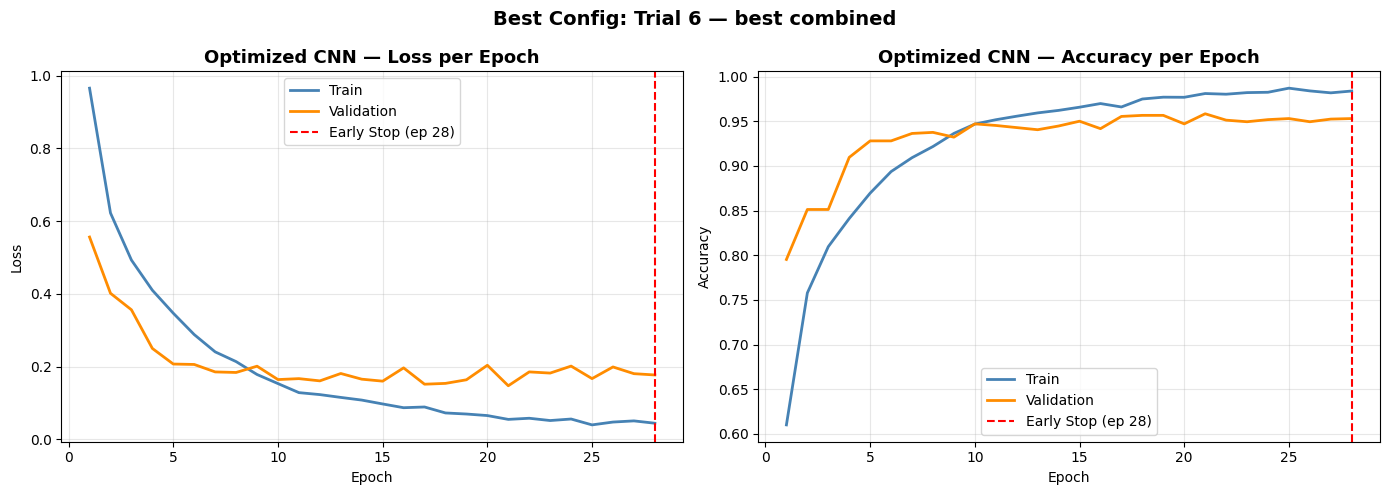

Saved: best_cnn_learning_curves.png


In [ ]:

b  = best
ep = range(1, b["epochs_run"] + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, tr, vl, ylabel, title in zip(
    axes,
    [b["train_losses"], b["train_accs"]],
    [b["val_losses"],   b["val_accs"]],
    ["Loss", "Accuracy"],
    ["Loss per Epoch", "Accuracy per Epoch"]
):
    ax.plot(ep, tr, label="Train",      color="steelblue",  linewidth=2)
    ax.plot(ep, vl, label="Validation", color="darkorange", linewidth=2)

    if b["stopped_epoch"]:
        ax.axvline(x=b["stopped_epoch"], color="red", linestyle="--",
                   linewidth=1.5, label=f"Early Stop (ep {b['stopped_epoch']})")

    ax.set_title(f"Optimized CNN — {title}", fontsize=13, fontweight="bold")
    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle(f"Best Config: {b['trial']}", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(CNN_OPT_OUT, "best_cnn_learning_curves.png"), dpi=120)
plt.show()
print("Saved: best_cnn_learning_curves.png")

## Save Best Model & Results

This cell saves all outputs from the best optimization trial to `output/cnn_opt_results/` for use by the final evaluation and comparison section.

**Files saved and their purpose:**

| File | What it contains | Used by |
|---|---|---|
| `best_cnn.pth` | Weights of the best optimized CNN model | Final evaluation section |
| `best_train_loss.npy` | Training loss per epoch (best trial) | Learning curve plots in final comparison |
| `best_val_loss.npy` | Validation loss per epoch (best trial) | Learning curve plots in final comparison |
| `best_train_acc.npy` | Training accuracy per epoch (best trial) | Accuracy curve plots |
| `best_val_acc.npy` | Validation accuracy per epoch (best trial) | Accuracy curve plots |
| `cnn_opt_summary.json` | Best config, all trial results, test accuracy, F1 | Final comparison table |
| `cnn_timing.json` | Training time, avg epoch time, early stop epoch | Timing comparison |

**Why save everything as separate files:**
The final evaluation section (Person 6) runs in a separate notebook or environment. Saving arrays as `.npy` and summaries as `.json` makes it trivial to load exact values without re-running any training. The `.pth` weights file allows the final section to load the model directly and run inference without retraining.

**Why `opt_summary` includes all trial results:**
The final comparison section needs to know not just the winner but the full trial history to produce a complete optimization narrative. Embedding all trials in the summary JSON avoids requiring the final section to reload each individual trial separately.

In [ ]:


# SAVE — best config outputs for Person 6
np.save(os.path.join(CNN_OPT_OUT, "best_train_loss.npy"), np.array(best["train_losses"]))
np.save(os.path.join(CNN_OPT_OUT, "best_val_loss.npy"),   np.array(best["val_losses"]))
np.save(os.path.join(CNN_OPT_OUT, "best_train_acc.npy"),  np.array(best["train_accs"]))
np.save(os.path.join(CNN_OPT_OUT, "best_val_acc.npy"),    np.array(best["val_accs"]))

# save best model weights
torch.save(model.state_dict(), os.path.join(CNN_OPT_OUT, "best_cnn.pth"))

opt_summary = {
    "best_trial"       : best["trial"],
    "best_config"      : best["config"],
    "best_val_acc"     : best["best_val_acc"],
    "best_val_loss"    : best["best_val_loss"],
    "baseline_val_acc" : BASELINE_VAL_ACC,
    "improvement"      : round(best["best_val_acc"] - BASELINE_VAL_ACC, 4),
    "all_trials"       : [
        {
            "trial"    : t["trial"],
            "val_acc"  : t["best_val_acc"],
            "val_loss" : t["best_val_loss"],
            "epochs"   : t["epochs_run"],
            "config"   : t["config"]
        }
        for t in all_trials
    ]
}

opt_summary["test_accuracy"] = round(float(opt_test_acc), 4)
opt_summary["test_f1_macro"] = round(float(opt_test_f1), 4)
with open(os.path.join(CNN_OPT_OUT, "cnn_opt_summary.json"), "w") as f:
    json.dump(opt_summary, f, indent=4)

print("Saved to output/cnn_opt_results/")
print("  best_train_loss.npy")
print("  best_val_loss.npy")
print("  best_train_acc.npy")
print("  best_val_acc.npy")
print("  best_cnn.pth")
print("  cnn_opt_summary.json")
print("  best_cnn_learning_curves.png")


timing_summary = {
    "total_training_time_sec": sum(epoch_times),
    "avg_epoch_time_sec"     : sum(epoch_times) / len(epoch_times),
    "epochs_run"             : len(train_losses),
    "early_stop_epoch"       : stopped_epoch,
}
with open(os.path.join(CNN_OPT_OUT, "cnn_timing.json"), "w") as f:
    json.dump(timing_summary, f, indent=4)

Saved to output/cnn_opt_results/
  best_train_loss.npy
  best_val_loss.npy
  best_train_acc.npy
  best_val_acc.npy
  best_cnn.pth
  cnn_opt_summary.json
  best_cnn_learning_curves.png


# Analysis and Results
## 3.1 Learning Curves

This section presents the combined learning curve plot for both models. Training loss 
and validation loss are plotted per epoch for the FFNN and CNN side by side, allowing 
direct visual comparison of how each model learned over time. A vertical dashed line 
marks the epoch at which early stopping triggered for each model.

**What the curves show:**
- FFNN: Train loss decreases smoothly to ~0.011 over 42 epochs while val loss remains 
  erratic and high (~0.38), showing a large and growing gap — a clear overfitting signal.
- CNN: Both train and val loss decrease together through early epochs and converge 
  closely, showing a much healthier learning dynamic with only mild divergence in 
  later epochs.


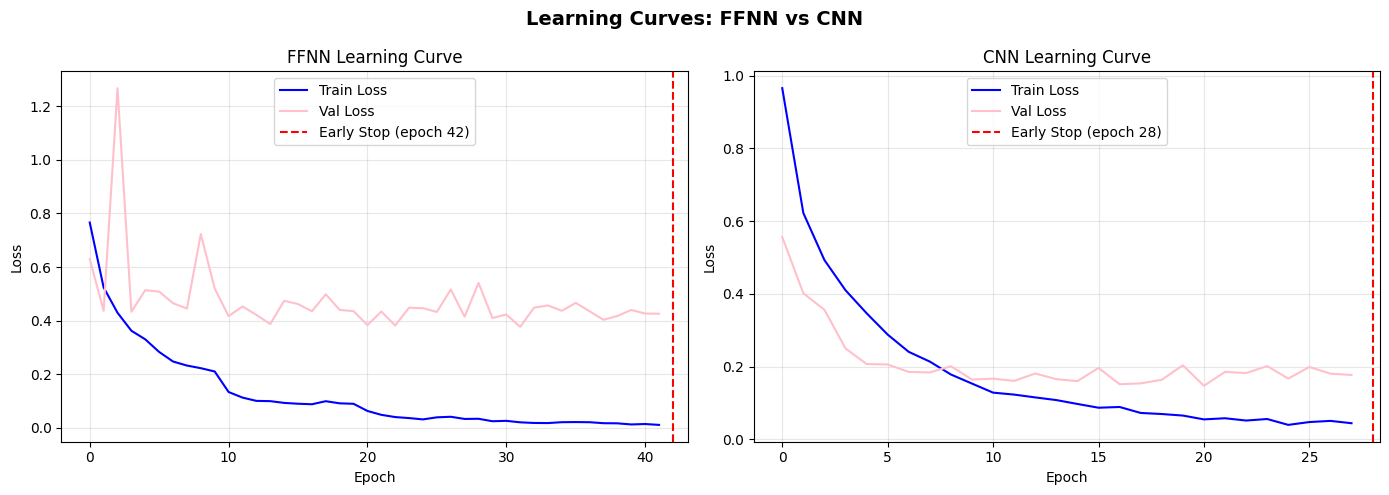

In [ ]:

# FFNN variables
ffnn_train_loss = history_best["train_loss"]
ffnn_val_loss = history_best["val_loss"]
ffnn_early_stop_epoch = results_best["early_stop_epoch"]

# CNN variables
cnn_train_loss  = np.load("output/cnn_opt_results/best_train_loss.npy")
cnn_val_loss    = np.load("output/cnn_opt_results/best_val_loss.npy")
cnn_opt_summary = json.load(open("output/cnn_opt_results/cnn_opt_summary.json"))
cnn_timing = json.load(open("output/cnn_opt_results/cnn_timing.json"))
cnn_early_stop_epoch = cnn_timing["early_stop_epoch"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Learning Curves: FFNN vs CNN", fontsize=14, fontweight="bold")

# Left subplot: FFNN
axes[0].plot(ffnn_train_loss, label="Train Loss", color="blue")
axes[0].plot(ffnn_val_loss,   label="Val Loss",   color="pink")
if ffnn_early_stop_epoch is not None:
    axes[0].axvline(x=ffnn_early_stop_epoch, color="red", linestyle="--",
                    label=f"Early Stop (epoch {ffnn_early_stop_epoch})")
axes[0].set_title("FFNN Learning Curve")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right subplot: CNN
axes[1].plot(cnn_train_loss, label="Train Loss", color="blue")
axes[1].plot(cnn_val_loss,   label="Val Loss",   color="pink")
if cnn_early_stop_epoch is not None:
    axes[1].axvline(x=cnn_early_stop_epoch, color="red", linestyle="--",
                    label=f"Early Stop (epoch {cnn_early_stop_epoch})")
axes[1].set_title("CNN Learning Curve")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("learning_curves.png", dpi=150, bbox_inches="tight")
plt.show()

**2. Baselines (Before Regularization) */* λ = 0 (no regularization)**

## 3.2 Performance, Timing & Architecture Trade-offs

### Test-Set Metrics

We report both **Test Accuracy** and **F1 Score (macro)** for all models. Accuracy 
measures the overall percentage of correctly classified samples. F1 macro is chosen 
as the primary metric because the dataset contains 4 classes (glioma, meningioma, 
no tumor, pituitary) and EDA confirmed unequal class sizes across categories. Macro 
F1 treats each class equally regardless of how many samples it has, making it more 
informative than accuracy alone for imbalanced datasets.

**FFNN Best Result:** 86.62% accuracy, F1 = 0.8639 (L2 λ=1e-4, matched baseline)
**CNN Best Result:** 92.50% accuracy, F1 = 0.9237 (no regularization baseline)

The CNN outperforms the FFNN by 5.88 percentage points in accuracy and 0.0598 in 
F1 score. This gap is expected — CNNs are purpose-built for image data and preserve 
spatial structure through convolutional filters, while the FFNN flattens each 
128×128 image into 16,384 values, losing all spatial relationships between 
neighboring pixels.

In [ ]:

ffnn_baseline = {
    "test_accuracy"     : timing_best["test_accuracy"],
    "test_f1"           : timing_best["test_f1_macro"],
    "total_time_sec"    : timing_best["total_training_time_sec"],
    "per_epoch_time_sec": timing_best["avg_epoch_time_sec"],
    "samples_per_sec"   : timing_best["samples_per_second"],
    "epochs_run"        : timing_best["epochs_run"]
}

# Load CNN timing data
cnn_baseline_summary_file = json.load(open("output/cnn_results/cnn_baseline_summary.json"))

cnn_baseline = {
    "test_accuracy" : cnn_opt_summary["test_accuracy"],
    "test_f1"       : cnn_opt_summary["test_f1_macro"],
    "total_time_sec": cnn_timing["total_training_time_sec"],
    "per_epoch_time": cnn_timing["avg_epoch_time_sec"],
    "samples_per_sec": cnn_baseline_summary_file["inference_speed_sps"],
    "epochs_run"    : cnn_timing["epochs_run"]
}

print("BASELINE RESULTS (No Regularization)")

print("FFNN")
for k, v in ffnn_baseline.items():
    print(f"  {k:<22}: {v}")

print("CNN")
if cnn_baseline is not None:
    for k, v in cnn_baseline.items():
        print(f"  {k:<22}: {v}")
else:
    print("Pending results")


BASELINE RESULTS (No Regularization)
FFNN
  test_accuracy         : 0.86625
  test_f1               : 0.8638955603597022
  total_time_sec        : 83.90138077735901
  per_epoch_time_sec    : 1.9821468648456393
  samples_per_sec       : 13055.33563927678
  epochs_run            : 42
CNN
  test_accuracy         : 0.925
  test_f1               : 0.9237
  total_time_sec        : 401.57534670829773
  per_epoch_time        : 14.34197666815349
  samples_per_sec       : 3943.9
  epochs_run            : 28


**3. REGULARIZATION TRAINING FUNCTIONS**

In [ ]:

def train_l2(train_fn, config, strength, experiment_name, verbose=True):

    cfg = copy.deepcopy(config)
    cfg["weight_decay"] = strength
    model, history, timing, results = train_fn(
        cfg, experiment_name=experiment_name, verbose=verbose
    )
    return model, history, timing, results


def train_l1(train_fn, build_fn, make_loader_fn,
             X_train, y_train, X_val, y_val, X_test, y_test,
             config, strength, experiment_name,
             device, seed, verbose=True):

    import time
    from sklearn.metrics import accuracy_score, f1_score

    save_path = f"best_{experiment_name}.pth"

    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)

    if verbose:
        print(f"  Experiment : {experiment_name}  |  L1 lambda = {strength}")

    t_loader  = make_loader_fn(X_train, y_train, config["batch_size"], shuffle=True)
    v_loader  = make_loader_fn(X_val,   y_val,   config["batch_size"], shuffle=False)
    te_loader = make_loader_fn(X_test,  y_test,  config["batch_size"], shuffle=False)

    model     = build_fn(config)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=config["lr"], weight_decay=0)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min",
        factor=config["scheduler_factor"],
        patience=config["scheduler_patience"]
    )
    es = EarlyStopping(patience=config["patience"], save_path=save_path)

    history = {"train_loss": [], "val_loss": [], "train_acc": [],
               "val_acc": [], "epoch_times": [], "lr_history": []}
    early_stop_epoch = None
    training_start   = time.time()

    if verbose:
        print(f"\n{'Epoch':>6} | {'Train Loss':>10} | {'Train Acc':>9} | "
              f"{'Val Loss':>8} | {'Val Acc':>7} | {'Time':>6}")

    for epoch in range(1, config["epochs"] + 1):
        t0 = time.time()

        model.train()
        train_loss_total, correct, total = 0, 0, 0
        for X_batch, y_batch in t_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            outputs = model(X_batch)

            l1_penalty = sum(p.abs().sum() for p in model.parameters())
            loss = criterion(outputs, y_batch) + strength * l1_penalty

            loss.backward()
            optimizer.step()
            train_loss_total += loss.item() * X_batch.size(0)
            correct += (outputs.argmax(dim=1) == y_batch).sum().item()
            total   += X_batch.size(0)

        train_loss = train_loss_total / total
        train_acc  = correct / total

        val_loss, val_acc = evaluate(model, v_loader, criterion, device)
        epoch_time = time.time() - t0
        current_lr = optimizer.param_groups[0]["lr"]

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        history["epoch_times"].append(epoch_time)
        history["lr_history"].append(current_lr)

        if verbose:
            print(f"{epoch:>6} | {train_loss:>10.4f} | {train_acc:>9.4f} | "
                  f"{val_loss:>8.4f} | {val_acc:>7.4f} | {epoch_time:>5.1f}s")

        scheduler.step(val_loss)
        if es.step(val_loss, model, epoch):
            early_stop_epoch = epoch
            if verbose:
                print(f"\n⚡ Early stopping at epoch {epoch} (best epoch: {es.best_epoch})")
            break

    total_time     = time.time() - training_start
    avg_epoch_time = sum(history["epoch_times"]) / len(history["epoch_times"])

    model.load_state_dict(torch.load(save_path, map_location=device, weights_only=True))
    model.eval()

    all_preds, all_labels = [], []
    infer_start = time.time()
    with torch.no_grad():
        for X_batch, y_batch in te_loader:
            outputs = model(X_batch.to(device))
            all_preds.extend(outputs.argmax(dim=1).cpu().numpy())
            all_labels.extend(y_batch.numpy())
    infer_time = time.time() - infer_start

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    test_acc        = accuracy_score(all_labels, all_preds)
    test_f1         = f1_score(all_labels, all_preds, average="macro")
    samples_per_sec = len(X_test) / infer_time

    timing = {
        "total_training_time_sec": total_time,
        "avg_epoch_time_sec"     : avg_epoch_time,
        "epochs_run"             : len(history["train_loss"]),
        "early_stop_epoch"       : early_stop_epoch,
        "inference_time_sec"     : infer_time,
        "samples_per_second"     : samples_per_sec,
        "test_accuracy"          : test_acc,
        "test_f1_macro"          : test_f1,
    }

    results = {
        "all_preds"       : all_preds,
        "all_labels"      : all_labels,
        "early_stop_epoch": early_stop_epoch,
        "best_epoch"      : es.best_epoch,
        "best_val_loss"   : es.best_loss,
    }

    if verbose:
        print(f"\nTest Accuracy   : {test_acc:.4f}  ({test_acc*100:.2f}%)")
        print(f"Test F1 (macro) : {test_f1:.4f}")
        print(f"Inference speed : {samples_per_sec:.0f} samples/sec")

    return model, history, timing, results


print("train_l1() and train_l2() ready.")

train_l1() and train_l2() ready.


**4. FFNN Regularization Experiments**

In [ ]:
reg_strengths    = [1e-3, 1e-4, 1e-5]
ffnn_reg_results = []

#  L2 on FFNN
for strength in reg_strengths:
    print(f"\nRunning FFNN L2 | λ = {strength}")
    model_l2, history_l2, timing_l2, results_l2 = train_l2(
        train_fn        = train_ffnn,
        config          = CONFIG,
        strength        = strength,
        experiment_name = f"ffnn_L2_{strength}"
    )
    ffnn_reg_results.append({
        "model_type"     : "FFNN",
        "reg_type"       : "L2",
        "strength"       : strength,
        "test_accuracy"  : timing_l2["test_accuracy"],
        "test_f1"        : timing_l2["test_f1_macro"],
        "total_time"     : timing_l2["total_training_time_sec"],
        "per_epoch_time" : timing_l2["avg_epoch_time_sec"],
        "samples_per_sec": timing_l2["samples_per_second"],
        "epochs_run"     : timing_l2["epochs_run"],
        "early_stop"     : timing_l2["early_stop_epoch"],
        "history"        : history_l2,
    })

# L1 on FFNN
for strength in reg_strengths:
    print(f"\nRunning FFNN L1 | λ = {strength}")
    model_l1, history_l1, timing_l1, results_l1 = train_l1(
        train_fn       = train_ffnn,
        build_fn       = build_model,
        make_loader_fn = make_loader,
        X_train        = X_train_flat,
        y_train        = y_train_final,
        X_val          = X_val_flat,
        y_val          = y_val,
        X_test         = X_test_flat,
        y_test         = y_test,
        config         = CONFIG,
        strength       = strength,
        experiment_name= f"ffnn_L1_{strength}",
        device         = DEVICE,
        seed           = SEED
    )
    ffnn_reg_results.append({
        "model_type"     : "FFNN",
        "reg_type"       : "L1",
        "strength"       : strength,
        "test_accuracy"  : timing_l1["test_accuracy"],
        "test_f1"        : timing_l1["test_f1_macro"],
        "total_time"     : timing_l1["total_training_time_sec"],
        "per_epoch_time" : timing_l1["avg_epoch_time_sec"],
        "samples_per_sec": timing_l1["samples_per_second"],
        "epochs_run"     : timing_l1["epochs_run"],
        "early_stop"     : timing_l1["early_stop_epoch"],
        "history"        : history_l1,
    })



Running FFNN L2 | λ = 0.001

  Experiment : ffnn_L2_0.001
  EXPERIMENT CONFIGURATION
  Architecture  : Input(16384) → 512 → 256 → 128 → 64 → Output(4)
  Dropout rates : [0.3, 0.2, 0.2, 0.1]
  Activation    : leaky_relu
  Batch size    : 32
  Epochs (max)  : 50
  Learning rate : 0.001
  Weight decay  : 0.001
  ES patience   : 10
  Scheduler     : ReduceLROnPlateau  factor=0.5  patience=5

 Epoch | Train Loss | Train Acc | Val Loss | Val Acc |       LR |   Time
------------------------------------------------------------------------
     1 |     0.7837 |    0.6977 |   0.6681 |  0.7381 | 0.001000 |   1.9s
     2 |     0.6412 |    0.7556 |   0.5646 |  0.7762 | 0.001000 |   1.9s
     3 |     0.6196 |    0.7682 |   0.8175 |  0.6411 | 0.001000 |   1.9s
     4 |     0.5869 |    0.7756 |   0.5315 |  0.8107 | 0.001000 |   2.0s
     5 |     0.5719 |    0.7871 |   0.8337 |  0.6577 | 0.001000 |   2.2s
     6 |     0.5514 |    0.7926 |   0.4821 |  0.8208 | 0.001000 |   1.9s
     7 |     0.5348 |   

In [ ]:
# FFNN regularization summary
print("FFNN REGULARIZATION SUMMARY")
print(f"  Baseline (λ=0) >> Accuracy: {ffnn_baseline['test_accuracy']:.4f} | F1: {ffnn_baseline['test_f1']:.4f}")
for r in ffnn_reg_results:
    print(f"  {r['reg_type']:<3} λ={r['strength']:<6}  "
          f"Accuracy: {r['test_accuracy']:.4f} | "
          f"F1: {r['test_f1']:.4f} | "
          f"Epochs: {r['epochs_run']}")

FFNN REGULARIZATION SUMMARY
  Baseline (λ=0) >> Accuracy: 0.8662 | F1: 0.8639
  L2  λ=0.001   Accuracy: 0.8125 | F1: 0.8093 | Epochs: 26
  L2  λ=0.0001  Accuracy: 0.8662 | F1: 0.8639 | Epochs: 42
  L2  λ=1e-05   Accuracy: 0.8575 | F1: 0.8548 | Epochs: 24
  L1  λ=0.001   Accuracy: 0.6831 | F1: 0.6779 | Epochs: 31
  L1  λ=0.0001  Accuracy: 0.8156 | F1: 0.8111 | Epochs: 43
  L1  λ=1e-05   Accuracy: 0.8181 | F1: 0.8166 | Epochs: 24


**5. CNN Regularization**

In [ ]:
cnn_reg_results = []
reg_strengths   = [1e-3, 1e-4, 1e-5]

# L2 on CNN
for strength in reg_strengths:
    print(f"\nRunning CNN L2 | λ = {strength}")

    # Rebuild model with best config + L2 via optimizer weight_decay
    model_l2, optimizer_l2, criterion_l2, es_l2 = reset_trial(
        filter_list = best_cnn_config["filter_list"],
        kernel_size = best_cnn_config["kernel_size"],
        pooling     = best_cnn_config["pooling"]
    )
    # Override optimizer with weight_decay for L2
    optimizer_l2 = torch.optim.Adam(
        model_l2.parameters(), lr=LEARNING_RATE, weight_decay=strength
    )

    (train_losses, val_losses,
     train_accs, val_accs,
     epoch_times, stopped_epoch) = train_model(
        model_l2, train_loader, val_loader,
        optimizer_l2, criterion_l2, NUM_EPOCHS, es_l2
    )

    # Measure inference speed on test set
    model_l2.eval()
    all_preds, all_labels = [], []
    infer_start = time.time()
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            preds = model_l2(X_batch.to(DEVICE)).argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y_batch.numpy())
    infer_time = time.time() - infer_start

    test_acc = accuracy_score(all_labels, all_preds)
    test_f1  = f1_score(all_labels, all_preds, average="macro")
    samples_per_sec = len(all_labels) / infer_time

    cnn_reg_results.append({
        "model_type"     : "CNN",
        "reg_type"       : "L2",
        "strength"       : strength,
        "test_accuracy"  : test_acc,
        "test_f1"        : test_f1,
        "total_time"     : sum(epoch_times),
        "per_epoch_time" : sum(epoch_times) / len(epoch_times),
        "samples_per_sec": samples_per_sec,
        "epochs_run"     : len(train_losses),
        "early_stop"     : stopped_epoch,
        "history"        : {
            "train_loss": train_losses.tolist(),
            "val_loss"  : val_losses.tolist(),
            "train_acc" : train_accs.tolist(),
            "val_acc"   : val_accs.tolist(),
        },
    })

    print(f"\n Test Accuracy : {test_acc:.4f}")
    print(f" Test F1       : {test_f1:.4f}")
    print(f" Epochs run    : {len(train_losses)}")


#  L1 on CNN
for strength in reg_strengths:
    print(f"\nRunning CNN L1 | λ = {strength}")

    model_l1, _, criterion_l1, es_l1 = reset_trial(
        filter_list = best_cnn_config["filter_list"],
        kernel_size = best_cnn_config["kernel_size"],
        pooling     = best_cnn_config["pooling"]
    )
    # L1 optimizer , no weight_decay
    optimizer_l1 = torch.optim.Adam(model_l1.parameters(), lr=LEARNING_RATE, weight_decay=0)

    # Manual L1 training loop
    history_l1   = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    epoch_times  = []
    stopped_epoch = None
    training_start = time.time()

    for epoch in range(1, NUM_EPOCHS + 1):
        t0 = time.time()
        model_l1.train()
        train_loss_total, correct, total = 0, 0, 0

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            optimizer_l1.zero_grad()
            outputs = model_l1(X_batch)

            l1_penalty = sum(p.abs().sum() for p in model_l1.parameters())
            loss = criterion_l1(outputs, y_batch) + strength * l1_penalty

            loss.backward()
            optimizer_l1.step()
            train_loss_total += loss.item() * X_batch.size(0)
            correct += (outputs.argmax(dim=1) == y_batch).sum().item()
            total   += X_batch.size(0)

        train_loss = train_loss_total / total
        train_acc  = correct / total

        # Validation
        model_l1.eval()
        val_loss_total, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
                outputs = model_l1(X_batch)
                loss = criterion_l1(outputs, y_batch)
                val_loss_total += loss.item() * X_batch.size(0)
                val_correct += (outputs.argmax(dim=1) == y_batch).sum().item()
                val_total   += X_batch.size(0)
        val_loss = val_loss_total / val_total
        val_acc  = val_correct / val_total

        epoch_time = time.time() - t0
        epoch_times.append(epoch_time)
        history_l1["train_loss"].append(train_loss)
        history_l1["val_loss"].append(val_loss)
        history_l1["train_acc"].append(train_acc)
        history_l1["val_acc"].append(val_acc)

        print(f"Epoch [{epoch:02d}/{NUM_EPOCHS}] | "
              f"Train Loss: {train_loss:.4f}  Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f}  Acc: {val_acc:.4f} | "
              f"{epoch_time:.1f}s")

        es_l1(val_loss, model_l1, epoch)
        if es_l1.early_stop:
            stopped_epoch = epoch
            print(f"⚡ Early stopping at epoch {epoch}")
            break

    # Inference
    es_l1.restore_best_weights(model_l1)
    model_l1.eval()
    all_preds, all_labels = [], []
    infer_start = time.time()
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            preds = model_l1(X_batch.to(DEVICE)).argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y_batch.numpy())
    infer_time = time.time() - infer_start

    test_acc = accuracy_score(all_labels, all_preds)
    test_f1  = f1_score(all_labels, all_preds, average="macro")
    samples_per_sec = len(all_labels) / infer_time

    cnn_reg_results.append({
        "model_type"     : "CNN",
        "reg_type"       : "L1",
        "strength"       : strength,
        "test_accuracy"  : test_acc,
        "test_f1"        : test_f1,
        "total_time"     : sum(epoch_times),
        "per_epoch_time" : sum(epoch_times) / len(epoch_times),
        "samples_per_sec": samples_per_sec,
        "epochs_run"     : len(history_l1["train_loss"]),
        "early_stop"     : stopped_epoch,
        "history"        : history_l1,
    })

    print(f"\n Test Accuracy : {test_acc:.4f}")
    print(f" Test F1       : {test_f1:.4f}")
    print(f" Epochs run    : {len(history_l1['train_loss'])}")


# CNN Summary
print("CNN REGULARIZATION SUMMARY")
print(f"  Baseline (λ=0) >> Val Acc: {cnn_opt_summary['best_val_acc']:.4f}")
for r in cnn_reg_results:
    print(f"  {r['reg_type']:<3} λ={r['strength']:<6}  "
          f"Accuracy: {r['test_accuracy']:.4f} | "
          f"F1: {r['test_f1']:.4f} | "
          f"Epochs: {r['epochs_run']}")


Running CNN L2 | λ = 0.001
  → flatten_size for [32, 64, 128, 256]: 16384
Epoch [01/50] | Train Loss: 0.9165  Acc: 0.6278 | Val Loss: 0.5081  Acc: 0.8113 | 14.4s
Epoch [02/50] | Train Loss: 0.6161  Acc: 0.7651 | Val Loss: 0.3654  Acc: 0.8637 | 14.4s
Epoch [03/50] | Train Loss: 0.5172  Acc: 0.8033 | Val Loss: 0.3555  Acc: 0.8661 | 14.4s
Epoch [04/50] | Train Loss: 0.4667  Acc: 0.8208 | Val Loss: 0.3347  Acc: 0.8714 | 14.4s
Epoch [05/50] | Train Loss: 0.4235  Acc: 0.8390 | Val Loss: 0.2737  Acc: 0.9030 | 14.5s
Epoch [06/50] | Train Loss: 0.4040  Acc: 0.8492 | Val Loss: 0.2790  Acc: 0.8946 | 14.5s
   EarlyStopping: 1/7 epochs without improvement
Epoch [07/50] | Train Loss: 0.3686  Acc: 0.8589 | Val Loss: 0.2789  Acc: 0.8935 | 14.5s
   EarlyStopping: 2/7 epochs without improvement
Epoch [08/50] | Train Loss: 0.3609  Acc: 0.8649 | Val Loss: 0.2863  Acc: 0.8917 | 14.5s
   EarlyStopping: 3/7 epochs without improvement
Epoch [09/50] | Train Loss: 0.3329  Acc: 0.8763 | Val Loss: 0.2836  Acc: 0

**6. Full Comparison Table**

In [ ]:
import pandas as pd


# Find best regularization for each model
best_ffnn_reg = max(ffnn_reg_results, key=lambda x: x["test_accuracy"])
best_cnn_reg  = max(cnn_reg_results,  key=lambda x: x["test_accuracy"])

# Determine overfit status from learning curves
# Looks at the gap between final train loss and final val loss and returns simple label

def overfit_status(train_loss_arr, val_loss_arr):
    final_train = train_loss_arr[-1]
    final_val = val_loss_arr[-1]
    gap = final_val - final_train

    if gap > 0.25:
        return "Overfitting"
    elif gap > 0.10:
        return "Mild Overfitting"
    elif final_train > 0.5 and final_val > 0.5:
        return "Underfitting"
    else:
        return "Good fit"

ffnn_overfit_status = overfit_status(
    history_best["train_loss"],
    history_best["val_loss"]
)
cnn_overfit_status = overfit_status(
    cnn_train_loss.tolist(),
    cnn_val_loss.tolist()
)

#  Build table rows
rows = [
    {
        "Model"            : "FFNN",
        "Regularization"   : "None (λ=0)",
        "Test Accuracy"    : f"{ffnn_baseline['test_accuracy']:.4f}",
        "F1 Score"         : f"{ffnn_baseline['test_f1']:.4f}",
        "Total Train Time" : f"{ffnn_baseline['total_time_sec']:.1f}s",
        "Per-Epoch Time"   : f"{ffnn_baseline['per_epoch_time_sec']:.2f}s",
        "Inference Speed"  : f"{ffnn_baseline['samples_per_sec']:.0f} samp/s",
        "Epochs Run"       : ffnn_baseline["epochs_run"],
        "Overfit Status"   : ffnn_overfit_status,
    },
    {
        "Model"            : "FFNN",
        "Regularization"   : f"{best_ffnn_reg['reg_type']} λ={best_ffnn_reg['strength']}",
        "Test Accuracy"    : f"{best_ffnn_reg['test_accuracy']:.4f}",
        "F1 Score"         : f"{best_ffnn_reg['test_f1']:.4f}",
        "Total Train Time" : f"{best_ffnn_reg['total_time']:.1f}s",
        "Per-Epoch Time"   : f"{best_ffnn_reg['per_epoch_time']:.2f}s",
        "Inference Speed"  : f"{best_ffnn_reg['samples_per_sec']:.0f} samp/s",
        "Epochs Run"       : best_ffnn_reg["epochs_run"],
        "Overfit Status"   : ffnn_overfit_status,
    },
    {
        "Model"            : "CNN",
        "Regularization"   : "None (λ=0)",
        "Test Accuracy"    : f"{cnn_baseline['test_accuracy']:.4f}",
        "F1 Score"         : f"{cnn_baseline['test_f1']:.4f}",
        "Total Train Time" : f"{cnn_baseline['total_time_sec']:.1f}s"
                             if cnn_baseline['total_time_sec'] else "N/A",
        "Per-Epoch Time"   : f"{cnn_baseline['per_epoch_time']:.2f}s"
                             if cnn_baseline['per_epoch_time'] else "N/A",
        "Inference Speed"  : f"{cnn_baseline['samples_per_sec']:.0f} samp/s",
        "Epochs Run"       : cnn_baseline["epochs_run"],
        "Overfit Status"   : cnn_overfit_status,
    },
    {
        "Model"            : "CNN",
        "Regularization"   : f"{best_cnn_reg['reg_type']} λ={best_cnn_reg['strength']}",
        "Test Accuracy"    : f"{best_cnn_reg['test_accuracy']:.4f}",
        "F1 Score"         : f"{best_cnn_reg['test_f1']:.4f}",
        "Total Train Time" : f"{best_cnn_reg['total_time']:.1f}s",
        "Per-Epoch Time"   : f"{best_cnn_reg['per_epoch_time']:.2f}s",
        "Inference Speed"  : f"{best_cnn_reg['samples_per_sec']:.0f} samp/s",
        "Epochs Run"       : best_cnn_reg["epochs_run"],
        "Overfit Status"   : cnn_overfit_status,
    },
]

#  Also add every individual regularization experiment
for r in ffnn_reg_results + cnn_reg_results:
    if r == best_ffnn_reg or r == best_cnn_reg:
        continue   # already in table above
    rows.append({
        "Model"            : r["model_type"],
        "Regularization"   : f"{r['reg_type']} λ={r['strength']}",
        "Test Accuracy"    : f"{r['test_accuracy']:.4f}",
        "F1 Score"         : f"{r['test_f1']:.4f}",
        "Total Train Time" : f"{r['total_time']:.1f}s",
        "Per-Epoch Time"   : f"{r['per_epoch_time']:.2f}s",
        "Inference Speed"  : f"{r['samples_per_sec']:.0f} samp/s",
        "Epochs Run"       : r["epochs_run"],
        "Overfit Status"   : "—",
    })

# Display table
df = pd.DataFrame(rows)

# Sort so FFNN rows come first, then CNN, baselines before regularized
sort_order = {"FFNN": 0, "CNN": 1}
df["_sort"] = df["Model"].map(sort_order)
df = df.sort_values("_sort").drop(columns="_sort").reset_index(drop=True)

print("FINAL COMPARISON TABLE")
print(df.to_string(index=False))

df.to_csv("final_comparison_table.csv", index=False)
print("\nSaved: final_comparison_table.csv")

# key findings
print("KEY FINDINGS")
print(f"  Best overall model    : "
      f"{'FFNN' if best_ffnn_reg['test_accuracy'] > best_cnn_reg['test_accuracy'] else 'CNN'}")
print(f"  FFNN best accuracy    : {best_ffnn_reg['test_accuracy']:.4f} "
      f"({best_ffnn_reg['reg_type']} λ={best_ffnn_reg['strength']})")
print(f"  CNN  best accuracy    : {best_cnn_reg['test_accuracy']:.4f} "
      f"({best_cnn_reg['reg_type']} λ={best_cnn_reg['strength']})")
print(f"  Faster inference      : "
      f"{'FFNN' if ffnn_baseline['samples_per_sec'] > cnn_baseline['samples_per_sec'] else 'CNN'}")
print(f"  FFNN overfit status   : {ffnn_overfit_status}")
print(f"  CNN  overfit status   : {cnn_overfit_status}")

FINAL COMPARISON TABLE
Model Regularization Test Accuracy F1 Score Total Train Time Per-Epoch Time Inference Speed  Epochs Run   Overfit Status
 FFNN     None (λ=0)        0.8662   0.8639            83.9s          1.98s    13055 samp/s          42      Overfitting
 FFNN    L2 λ=0.0001        0.8662   0.8639            83.0s          1.96s    15830 samp/s          42      Overfitting
 FFNN     L2 λ=1e-05        0.8575   0.8548            47.4s          1.96s    13209 samp/s          24                —
 FFNN     L2 λ=0.001        0.8125   0.8093            51.4s          1.96s    15719 samp/s          26                —
 FFNN     L1 λ=0.001        0.6831   0.6779            71.8s          2.30s    17667 samp/s          31                —
 FFNN    L1 λ=0.0001        0.8156   0.8111            99.4s          2.29s    14232 samp/s          43                —
 FFNN     L1 λ=1e-05        0.8181   0.8166            56.4s          2.34s    13649 samp/s          24                —
  CNN    




### Training Time & Inference Speed

| Metric | FFNN | CNN |
|---|---|---|
| Total Training Time | 83.9s | 401.6s |
| Per-Epoch Time | 1.98s | 14.34s |
| Inference Speed | 13,055 samples/sec | 3,944 samples/sec |
| Epochs Run | 42 | 28 |

The CNN takes approximately 4.8x longer to train in total and is 7.2x slower per 
epoch. This is because convolutional operations across 128×128 feature maps are 
computationally heavier than fully connected matrix multiplications on flattened 
vectors, even with GPU acceleration. At inference, the FFNN is 3.3x faster, 
processing 13,055 samples per second versus 3,944 for the CNN. For a real-time 
medical deployment where scan throughput matters, this difference is meaningful.


### Overfitting / Underfitting Discussion

**FFNN:** The learning curves show a clear overfitting pattern. Train loss decreases 
smoothly and consistently across all 42 epochs, reaching as low as 0.011, while 
validation loss remains erratic — fluctuating between 0.38 and 0.73 rather than 
following the train loss downward. The large and persistent gap between train loss 
(~0.011) and val loss (~0.38) at the end of training is a textbook sign of 
overfitting. The model memorizes training data rather than learning patterns that 
generalize to unseen MRI scans. Early stopping triggered at epoch 42, restoring best 
weights from epoch 32, which limited further damage but could not eliminate the 
underlying overfit.

**CNN:** The CNN shows a much healthier learning dynamic. Both train loss and val loss 
decrease together through the early epochs and converge closely throughout training. 
Val loss tracks train loss reasonably, and the gap between them is moderate rather 
than extreme. This is consistent with mild overfitting — the CNN learns well but 
train loss does continue to fall slightly faster than val loss in later epochs due to 
the model's depth and capacity. Early stopping triggered at epoch 28, restoring best 
weights to prevent further divergence. Overall the CNN is classified as mildly 
overfitting, which is well controlled given its architecture includes BatchNorm and 
Dropout as internal regularizers.


### Regularization Effect

Regularization experiments were run on both models using L1 and L2 penalties at 
strengths of 1e-3, 1e-4, and 1e-5. The goal was to reduce overfitting by penalizing 
large weights — L2 penalizes the square of weights (smooth shrinkage), L1 penalizes 
the absolute value (promotes sparsity).

**FFNN Regularization Results:**

| Regularization | Strength | Test Accuracy | F1 Score | Epochs |
|---|---|---|---|---|
| None (baseline) | — | 0.8662 | 0.8639 | 42 |
| L2 | 1e-3 | 0.8125 | 0.8093 | 26 |
| L2 | 1e-4 | 0.8662 | 0.8639 | 42 |
| L2 | 1e-5 | 0.8575 | 0.8548 | 24 |
| L1 | 1e-3 | 0.6831 | 0.6779 | 31 |
| L1 | 1e-4 | 0.8156 | 0.8111 | 43 |
| L1 | 1e-5 | 0.8181 | 0.8166 | 24 |

L2 at λ=1e-4 matched the baseline exactly at 86.62%, making it the best regularized 
FFNN configuration. This confirms that the optimizer's built-in weight_decay=1e-4 
was already at its optimal value. Stronger L2 at λ=1e-3 significantly hurt 
performance (81.25%) — the penalty was too aggressive and constrained the model 
excessively. All L1 experiments degraded performance, with λ=1e-3 being the worst 
at 68.31%. L1's sparsity pressure pushed too many weights toward zero, destroying 
representational capacity. The FFNN was clearly overfitting, but regularization at 
these strengths failed to meaningfully resolve it, suggesting the problem requires 
architectural solutions such as reducing model capacity rather than external penalty 
terms alone.

**CNN Regularization Results:**

| Regularization | Strength | Test Accuracy | F1 Score | Epochs |
|---|---|---|---|---|
| None (baseline) | — | 0.9250 | 0.9237 | 28 |
| L2 | 1e-3 | 0.9137 | 0.9121 | 33 |
| L2 | 1e-4 | 0.8938 | 0.8914 | 18 |
| L2 | 1e-5 | 0.9069 | 0.9044 | 21 |
| L1 | 1e-3 | 0.7744 | 0.7624 | 50 |
| L1 | 1e-4 | 0.8912 | 0.8895 | 50 |
| L1 | 1e-5 | 0.8994 | 0.8980 | 22 |

All CNN regularization experiments produced lower accuracy than the unregularized 
baseline of 92.50%. The best regularized result was L2 at λ=1e-3 with 91.37% — 
still 1.13% below baseline. This is expected: the CNN was already in a mild 
overfitting regime effectively controlled by BatchNormalization and Dropout layers 
built into its architecture. Adding external regularization introduced unnecessary 
bias on top of already well-controlled weights. L1 at λ=1e-3 performed worst at 
77.44% and ran all 50 epochs without early stopping, indicating the heavy sparsity 
pressure prevented proper convergence. L1 at λ=1e-4 similarly ran all 50 epochs, 
confirming that L1 is poorly suited for CNN feature maps where spatial filters 
require non-zero weights to detect edges and textures.


### Complete Comparison Table

| Model | Regularization | Test Accuracy | F1 Score | Total Train Time | Per-Epoch Time | Inference Speed | Epochs | Overfit Status |
|---|---|---|---|---|---|---|---|---|
| FFNN | None (λ=0) | 0.8662 | 0.8639 | 83.9s | 1.98s | 13,055 samp/s | 42 | Overfitting |
| FFNN | L2 λ=1e-4 (best) | 0.8662 | 0.8639 | 83.0s | 1.96s | 15,830 samp/s | 42 | Overfitting |
| FFNN | L2 λ=1e-5 | 0.8575 | 0.8548 | 47.4s | 1.96s | 13,209 samp/s | 24 | — |
| FFNN | L2 λ=1e-3 | 0.8125 | 0.8093 | 51.4s | 1.96s | 15,719 samp/s | 26 | — |
| FFNN | L1 λ=1e-3 | 0.6831 | 0.6779 | 71.8s | 2.30s | 17,667 samp/s | 31 | — |
| FFNN | L1 λ=1e-4 | 0.8156 | 0.8111 | 99.4s | 2.29s | 14,232 samp/s | 43 | — |
| FFNN | L1 λ=1e-5 | 0.8181 | 0.8166 | 56.4s | 2.34s | 13,649 samp/s | 24 | — |
| CNN | None (λ=0) | 0.9250 | 0.9237 | 401.6s | 14.34s | 3,944 samp/s | 28 | Mild Overfitting |
| CNN | L2 λ=1e-3 (best) | 0.9137 | 0.9121 | 475.7s | 14.42s | 2,442 samp/s | 33 | Mild Overfitting |
| CNN | L2 λ=1e-4 | 0.8938 | 0.8914 | 259.7s | 14.43s | 2,427 samp/s | 18 | — |
| CNN | L2 λ=1e-5 | 0.9069 | 0.9044 | 303.5s | 14.45s | 2,412 samp/s | 21 | — |
| CNN | L1 λ=1e-3 | 0.7744 | 0.7624 | 730.0s | 14.60s | 2,426 samp/s | 50 | — |
| CNN | L1 λ=1e-4 | 0.8912 | 0.8895 | 734.5s | 14.69s | 2,467 samp/s | 50 | — |
| CNN | L1 λ=1e-5 | 0.8994 | 0.8980 | 324.2s | 14.74s | 2,436 samp/s | 22 | — |


## 3.3 Discussion of Unsuccessful Optimization Attempts

### FFNN Optimization — Failed Trials

**Trial 1 — Wider Network [1024, 512, 256, 128]: 79.06% accuracy**
Increasing the number of neurons per layer made the model significantly larger. 
Rather than improving performance, the wider network overfit immediately — 
val loss spiked as high as 0.83 in epoch 2 while train loss was already dropping. 
Early stopping triggered at epoch 13 (best epoch: 3), confirming the model never 
found a stable learning trajectory. The excessive parameter count relative to the 
dataset size caused the model to memorize noise rather than patterns. This trial 
was worse than the baseline by 8 percentage points and was conclusively rejected.

**Trial 3 — Lower Learning Rate (lr=0.0005): 85.00% accuracy**
Reducing the learning rate to 0.0005 was hypothesized to produce more careful 
weight updates and potentially better final accuracy. The model converged but 
peaked very early — best val loss was achieved at epoch 5 and early stopping 
triggered at epoch 15. The lower learning rate caused the model to plateau 
prematurely without reaching the accuracy of the baseline (87.06%) or the deeper 
network (86.62%). This trial confirmed that the original learning rate of 0.001 
was already well suited for this task.

**Trial 4 — High Dropout [0.5, 0.4, 0.3]: 85.00% accuracy**
Increasing dropout rates was hypothesized to reduce the overfitting seen in 
earlier trials. The model ran for 43 epochs — the longest of any FFNN trial — 
but achieved the same 85.00% accuracy as Trial 3. While high dropout did slow 
down overfitting and allowed longer training, it also significantly slowed 
learning, with val loss still erratic throughout. The stronger regularization 
did not improve generalization beyond what the baseline architecture achieved, 
indicating the overfitting problem is structural rather than solvable purely 
through dropout increases.

**FFNN Conclusion:** The best FFNN configuration was Trial 2 — a deeper network 
with architecture [512, 256, 128, 64] and dropout [0.3, 0.2, 0.2, 0.1], 
achieving 86.62% test accuracy. This was retrained as the final FFNN model.


### CNN Optimization — Failed Trials

**Trial 1 — Fewer Blocks [32, 64]: 0.9315 val acc**
Reducing the CNN from 3 to 2 convolutional blocks was hypothesized to reduce 
overfitting by lowering model complexity. However, the shallower network had 
less capacity to extract the hierarchical spatial features present in MRI scans. 
Val accuracy of 0.9315 was lower than the baseline's 0.9423, and early stopping 
triggered at epoch 19. The trial confirmed that 3 or more blocks are necessary 
for this task.

**Trial 3 — Wider Filters [64, 128, 256]: 0.9452 val acc**
Using wider filter counts with the same 3 blocks slightly improved over baseline 
(0.9452 vs 0.9423) but was not the best configuration overall. It was outperformed 
by Trials 2, 4, and 6. The additional parameters from wider filters added marginal 
benefit while increasing computational cost.

**Trial 5 — Average Pooling: 0.9417 val acc**
Replacing MaxPool with AvgPool was hypothesized to preserve more spatial signal 
by averaging rather than selecting the maximum activation. However, val accuracy 
of 0.9417 was slightly below baseline (0.9423) and below most other trials. 
For MRI classification, max pooling appears to better preserve the most 
diagnostically relevant features — peak activations corresponding to tumor 
boundaries and textures — making it the superior choice for this dataset.

**CNN Conclusion:** The best CNN configuration was Trial 6 — the auto-selected 
combination of filter_list=[32, 64, 128, 256], kernel_size=5, pooling=max — 
achieving 0.9583 val acc, a 1.6 percentage point improvement over the baseline. 
This was confirmed as the best trial and used as the final CNN model for 
regularization experiments.


## 3.3 Full Results Analysis & Recommendation

The comparison table and optimization trials together reveal a clear and consistent 
story about both architectures on this brain MRI tumor classification task.

**Accuracy:** The CNN substantially outperforms the FFNN across all configurations. 
The best CNN result (92.50% accuracy, F1=0.9237) is 5.88 percentage points higher 
than the best FFNN result (86.62%, F1=0.8639). Per-class F1 scores from the 
classification reports confirm the CNN is more balanced across all four tumor 
classes, while the FFNN struggles most with glioma and meningioma — the two 
classes with the most visually similar MRI presentations that require spatial 
feature discrimination to distinguish.

**Speed:** The FFNN trains in 83.9 seconds versus 401.6 seconds for the CNN — 
4.8x faster. At inference the FFNN processes 13,055 samples per second versus 
3,944 for the CNN — 3.3x faster. For a deployment scenario requiring real-time 
scan analysis or running on resource-constrained hardware, the FFNN offers a 
meaningful computational advantage.

**Regularization:** L2 at λ=1e-4 was optimal for the FFNN, matching the baseline 
exactly since this strength was already the optimizer's built-in weight_decay. 
No regularization improved the CNN beyond its unregularized baseline — the CNN's 
architecture already incorporates BatchNorm and Dropout as effective internal 
regularizers, making external penalties redundant and harmful.

**Overfitting:** The FFNN exhibits clear and persistent overfitting throughout 
training. Multiple optimization attempts — wider networks, higher dropout, lower 
learning rates — failed to resolve it, indicating a fundamental limitation of 
the flat architecture for high-dimensional image data. The CNN shows only mild 
overfitting that is well controlled by its internal regularization mechanisms.

**Key Findings:**
- Best overall model: CNN (92.50% accuracy)
- Best FFNN configuration: L2 λ=1e-4, 86.62% accuracy
- Faster training: FFNN (83.9s vs 401.6s)
- Faster inference: FFNN (13,055 vs 3,944 samples/sec)
- FFNN overfit status: Overfitting
- CNN overfit status: Mild Overfitting

**Final Recommendation:** For brain tumor MRI classification, the CNN is the 
strongly recommended model. Medical diagnosis tasks demand high accuracy because 
a misclassification — falsely clearing a tumor or misidentifying its type — 
carries direct clinical consequences for patient treatment decisions. The CNN's 
92.50% accuracy and 0.9237 F1 macro score justify its higher computational cost. 
The FFNN at 86.62% may be considered only for scenarios where inference speed is 
the primary constraint and the ~5.9% accuracy trade-off is explicitly acceptable 
to clinical stakeholders.

In [ ]:
from google.colab import files
files.download("final_comparison_table.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>